In [1]:
# 1. 라이브러리

import os
import copy
import numpy as np
import pandas as pd
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

In [2]:
import torch
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 4060


In [3]:
# 2. 4~8월 cargo CSV 로딩

file_paths = [
    r"C:\Users\HP\Desktop\prE\04cargo.csv",
    r"C:\Users\HP\Desktop\prE\05cargo.csv",
    r"C:\Users\HP\Desktop\prE\06cargo.csv",
    r"C:\Users\HP\Desktop\prE\07cargo.csv",
    r"C:\Users\HP\Desktop\prE\08cargo.csv",
]

df_list = []

for path in file_paths:
    temp = pd.read_csv(path)
    temp["source_file"] = os.path.basename(path)
    df_list.append(temp)

df_raw = pd.concat(df_list, ignore_index=True)

print(df_raw.shape)
print(df_raw.columns)
df_raw.head()

(4500839, 20)
Index(['MMSI', 'Date', 'Lat', 'Long', 'SOG', 'COG', 'Heading', 'Name', 'Type',
       'IMO', 'Call', 'DimA', 'DimB', 'DimC', 'DimD', 'Draft', 'Tons',
       'Length', 'Breadth', 'source_file'],
      dtype='str')


,MMSI,Date,Lat,Long,SOG,COG,Heading,Name,Type,IMO,Call,DimA,DimB,DimC,DimD,Draft,Tons,Length,Breadth,source_file
0,215331000,2024-04-01 00:02:56,35.067482,128.808068,0.0,285.7,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv
1,215331000,2024-04-01 00:05:56,35.067487,128.808107,0.0,233.2,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv
2,215331000,2024-04-01 00:08:56,35.067478,128.808130,0.0,236.5,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv
3,215331000,2024-04-01 00:11:56,35.067490,128.808120,0.0,242.4,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv
4,215331000,2024-04-01 00:14:56,35.067518,128.808348,0.0,238.9,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv


In [4]:
# 3. 기본 전처리

df = df_raw[["MMSI", "Date", "Lat", "Long", "SOG", "COG", "Heading", "source_file"]].copy()

df = df.rename(columns={
    "Date": "timestamp",
    "Lat": "lat",
    "Long": "lon",
    "SOG": "sog",
    "COG": "cog",
    "Heading": "heading"
})

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

for col in ["lat", "lon", "sog", "cog", "heading"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["MMSI", "timestamp", "lat", "lon", "sog", "cog", "heading"])

df = df[
    (df["lat"].between(-90, 90)) &
    (df["lon"].between(-180, 180)) &
    (df["sog"] >= 0) &
    (df["cog"].between(0, 360)) &
    (df["heading"].between(0, 360))
].copy()

df = df.sort_values(["MMSI", "timestamp"]).reset_index(drop=True)
df["month"] = df["timestamp"].dt.month

print(df.shape)
print(df["month"].value_counts().sort_index())
df.head()

(4417967, 9)
month
4    826933
5    900471
6    907346
7    912136
8    871081
Name: count, dtype: int64


,MMSI,timestamp,lat,lon,sog,cog,heading,source_file,month
0,209079000,2024-08-05 03:42:22,34.960100,128.823167,9.9,339.7,338,08cargo.csv,8
1,209079000,2024-08-05 03:42:32,34.960518,128.822972,9.8,339.7,338,08cargo.csv,8
2,209079000,2024-08-05 03:42:42,34.960935,128.822775,9.6,339.1,338,08cargo.csv,8
3,209079000,2024-08-05 03:42:52,34.961335,128.822592,9.4,338.6,338,08cargo.csv,8
4,209079000,2024-08-05 03:43:02,34.961732,128.822387,9.3,338.0,338,08cargo.csv,8


In [5]:
# 4. 선박 상태 라벨 생성
# 학습/검증/테스트에는 전체 AIS 데이터를 사용한다.
# 단, sog 기준으로 이동/저속 상태를 라벨링해서 뒤쪽 분석에 활용한다.

MOVING_THRESHOLD = 0.5

moving_df = df.copy()
moving_df["is_moving"] = moving_df["sog"] > MOVING_THRESHOLD

stationary_df = moving_df[moving_df["sog"] <= MOVING_THRESHOLD].copy()
active_df = moving_df[moving_df["sog"] > MOVING_THRESHOLD].copy()

print("전체 데이터:", len(df))
print("학습/예측 사용 데이터:", len(moving_df))
print("이동 상태 데이터:", len(active_df))
print("정지/저속 상태 데이터:", len(stationary_df))
print("이동 상태 비율:", round(len(active_df) / len(moving_df) * 100, 2), "%")
print("정지/저속 상태 비율:", round(len(stationary_df) / len(moving_df) * 100, 2), "%")

전체 데이터: 4417967
학습/예측 사용 데이터: 4417967
이동 상태 데이터: 2614784
정지/저속 상태 데이터: 1803183
이동 상태 비율: 59.19 %
정지/저속 상태 비율: 40.81 %


In [6]:
# 원본 moving_df 기준 AIS 수신 간격 분포 확인

interval_df = []

for mmsi, group in moving_df.groupby("MMSI"):
    group = group.sort_values("timestamp")
    dt_sec = group["timestamp"].diff().dt.total_seconds().dropna()

    if len(dt_sec) == 0:
        continue

    interval_df.append(pd.DataFrame({
        "MMSI": mmsi,
        "dt_sec": dt_sec
    }))

interval_df = pd.concat(interval_df, ignore_index=True)

display(interval_df["dt_sec"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

print("30초 이하 비율:", (interval_df["dt_sec"] <= 30).mean())
print("60초 이하 비율:", (interval_df["dt_sec"] <= 60).mean())
print("120초 이하 비율:", (interval_df["dt_sec"] <= 120).mean())
print("300초 이하 비율:", (interval_df["dt_sec"] <= 300).mean())

count    4.416601e+06
mean     1.242474e+03
std      7.518224e+04
min      0.000000e+00
10%      5.000000e+00
25%      9.000000e+00
50%      1.000000e+01
75%      1.200000e+01
90%      1.800000e+02
max      1.249734e+07
Name: dt_sec, dtype: float64

30초 이하 비율: 0.7840932427448166
60초 이하 비율: 0.7849656330739408
120초 이하 비율: 0.786191236201776
300초 이하 비율: 0.9926194374361641


In [7]:
# 5. Grid 설정

TRAIN_GRID_NM = 0.1
BASE_LAT_FOR_LON_SCALE = 35.0

TRAIN_LAT_GRID_SIZE = (TRAIN_GRID_NM * 1.852) / 111
TRAIN_LON_GRID_SIZE = (TRAIN_GRID_NM * 1.852) / (
    111 * np.cos(np.radians(BASE_LAT_FOR_LON_SCALE))
)

print("TRAIN_LAT_GRID_SIZE:", TRAIN_LAT_GRID_SIZE)
print("TRAIN_LON_GRID_SIZE:", TRAIN_LON_GRID_SIZE)

TRAIN_LAT_GRID_SIZE: 0.0016684684684684687
TRAIN_LON_GRID_SIZE: 0.0020368239084560514


In [8]:
# 6. 30초 단위 resampling
# 선형보간 없음. 실제 관측이 있는 30초 bin만 사용.

RESAMPLE_INTERVAL = "30s"
STEP_SECONDS = 30

MAX_REASONABLE_SPEED_KNOTS = 40


def circular_mean_deg(series):
    values = series.dropna().values

    if len(values) == 0:
        return np.nan

    radians = np.radians(values)
    sin_mean = np.mean(np.sin(radians))
    cos_mean = np.mean(np.cos(radians))

    angle = np.degrees(np.arctan2(sin_mean, cos_mean))
    return angle + 360 if angle < 0 else angle


def haversine_km_np(lat1, lon1, lat2, lon2):
    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return R * 2 * np.arcsin(np.sqrt(a))


def resample_ais_30s(df, progress_step=10):
    result = []
    grouped = list(df.groupby("MMSI"))
    total = len(grouped)
    next_progress = progress_step

    print(f"30s resampling start: {total} vessels")

    for idx, (mmsi, group) in enumerate(grouped, start=1):
        group = group.sort_values("timestamp").set_index("timestamp")

        resampled = group[["lat", "lon", "sog"]].resample(RESAMPLE_INTERVAL).mean()
        resampled["cog"] = group["cog"].resample(RESAMPLE_INTERVAL).apply(circular_mean_deg)
        resampled["heading"] = group["heading"].resample(RESAMPLE_INTERVAL).apply(circular_mean_deg)

        resampled = resampled.dropna()
        resampled["MMSI"] = mmsi
        result.append(resampled.reset_index())

        progress = idx / total * 100 if total else 100
        if progress >= next_progress or idx == total:
            print(f"resampling progress: {progress:.1f}% ({idx}/{total})")
            next_progress += progress_step

    if len(result) == 0:
        return pd.DataFrame(columns=["timestamp", "lat", "lon", "sog", "cog", "heading", "MMSI"])

    return pd.concat(result, ignore_index=True)


def remove_unrealistic_jumps(df, max_speed_knots=MAX_REASONABLE_SPEED_KNOTS):
    cleaned = []
    removed = 0

    for mmsi, group in df.groupby("MMSI"):
        group = group.sort_values("timestamp").copy()

        prev_lat = group["lat"].shift(1)
        prev_lon = group["lon"].shift(1)
        prev_time = group["timestamp"].shift(1)

        dt_hours = (group["timestamp"] - prev_time).dt.total_seconds() / 3600
        dist_km = haversine_km_np(prev_lat, prev_lon, group["lat"], group["lon"])
        speed_knots = (dist_km / 1.852) / dt_hours

        valid = prev_time.isna() | (
            (dt_hours > 0) &
            (speed_knots <= max_speed_knots)
        )

        removed += int((~valid).sum())
        cleaned.append(group.loc[valid])

    result = pd.concat(cleaned, ignore_index=True) if cleaned else df.iloc[0:0].copy()
    print("Removed unrealistic jump rows:", removed)
    return result


def add_direction_features(df):
    result = df.copy()

    result["cog_sin"] = np.sin(np.radians(result["cog"]))
    result["cog_cos"] = np.cos(np.radians(result["cog"]))
    result["heading_sin"] = np.sin(np.radians(result["heading"]))
    result["heading_cos"] = np.cos(np.radians(result["heading"]))

    return result

In [9]:
# 7. Train / Validation / Test split
# Train: 4월
# Validation: 5~7월
# Test: 8월

train_month_raw = moving_df[moving_df["month"].isin([4])].copy()
val_month_raw = moving_df[moving_df["month"].isin([5, 6, 7])].copy()
test_month_raw = moving_df[moving_df["month"].isin([8])].copy()

train_raw = add_direction_features(remove_unrealistic_jumps(resample_ais_30s(train_month_raw)))
val_raw = add_direction_features(remove_unrealistic_jumps(resample_ais_30s(val_month_raw)))
test_raw = add_direction_features(remove_unrealistic_jumps(resample_ais_30s(test_month_raw)))

for split_df in [train_raw, val_raw, test_raw]:
    split_df["month"] = split_df["timestamp"].dt.month

print("train_raw:", train_raw.shape)
print("val_raw:", val_raw.shape)
print("test_raw:", test_raw.shape)

30s resampling start: 537 vessels
resampling progress: 10.1% (54/537)
resampling progress: 20.1% (108/537)
resampling progress: 30.2% (162/537)
resampling progress: 40.0% (215/537)
resampling progress: 50.1% (269/537)
resampling progress: 60.1% (323/537)
resampling progress: 70.0% (376/537)
resampling progress: 80.1% (430/537)
resampling progress: 90.1% (484/537)
resampling progress: 100.0% (537/537)
Removed unrealistic jump rows: 1
30s resampling start: 1096 vessels
resampling progress: 10.0% (110/1096)
resampling progress: 20.1% (220/1096)
resampling progress: 30.0% (329/1096)
resampling progress: 40.1% (439/1096)
resampling progress: 50.0% (548/1096)
resampling progress: 60.0% (658/1096)
resampling progress: 70.1% (768/1096)
resampling progress: 80.0% (877/1096)
resampling progress: 90.1% (987/1096)
resampling progress: 100.0% (1096/1096)
Removed unrealistic jump rows: 658
30s resampling start: 521 vessels
resampling progress: 10.2% (53/521)
resampling progress: 20.2% (105/521)
resa

In [10]:
# 8. 정규화
# target은 다음 30초 delta_lat / delta_lon

feature_cols = [
    "lat", "lon", "sog",
    "cog_sin", "cog_cos",
    "heading_sin", "heading_cos"
]
target_cols = ["delta_lat", "delta_lon"]

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()


def build_delta_target_frame(raw_df):
    rows = []
    expected_delta = pd.Timedelta(seconds=STEP_SECONDS)

    for _, group in raw_df.groupby("MMSI"):
        group = group.sort_values("timestamp").reset_index(drop=True)

        next_lat = group["lat"].shift(-1)
        next_lon = group["lon"].shift(-1)
        next_time = group["timestamp"].shift(-1)

        is_continuous = (next_time - group["timestamp"]) == expected_delta

        delta_df = pd.DataFrame({
            "delta_lat": next_lat - group["lat"],
            "delta_lon": next_lon - group["lon"]
        })

        rows.append(delta_df.loc[is_continuous].dropna())

    if len(rows) == 0:
        return pd.DataFrame(columns=target_cols)

    return pd.concat(rows, ignore_index=True)


train_delta_targets = build_delta_target_frame(train_raw)

x_scaler.fit(train_raw[feature_cols])
y_scaler.fit(train_delta_targets[target_cols])


def apply_scaling(raw_df):
    norm_df = raw_df.copy()
    norm_df[feature_cols] = x_scaler.transform(raw_df[feature_cols])
    return norm_df


train_norm = apply_scaling(train_raw)
val_norm = apply_scaling(val_raw)
test_norm = apply_scaling(test_raw)

print("train delta target rows:", len(train_delta_targets))

train delta target rows: 194154


In [11]:
# 9. Interaction transition statistics

def latlon_to_grid(lat, lon, lat_min, lon_min, lat_grid_size, lon_grid_size):
    row = int((lat - lat_min) / lat_grid_size)
    col = int((lon - lon_min) / lon_grid_size)
    return row, col


def build_interaction_counts(df):
    transition_counts = defaultdict(int)

    lat_min = df["lat"].min()
    lon_min = df["lon"].min()

    for _, group in df.groupby("MMSI"):
        group = group.sort_values("timestamp")
        coords = group[["lat", "lon"]].values

        for i in range(len(coords) - 1):
            g1 = latlon_to_grid(
                coords[i][0], coords[i][1],
                lat_min, lon_min,
                TRAIN_LAT_GRID_SIZE, TRAIN_LON_GRID_SIZE
            )
            g2 = latlon_to_grid(
                coords[i + 1][0], coords[i + 1][1],
                lat_min, lon_min,
                TRAIN_LAT_GRID_SIZE, TRAIN_LON_GRID_SIZE
            )
            transition_counts[(g1, g2)] += 1

    return transition_counts, lat_min, lon_min


transition_counts, train_lat_min, train_lon_min = build_interaction_counts(train_raw)

print("interaction transitions:", len(transition_counts))

interaction transitions: 5159


In [12]:
# 10. Multi-Graph 생성

DISTANCE_GRAPH_SIGMA_KM = 0.5


def create_distance_graph(raw_seq, sigma_km=DISTANCE_GRAPH_SIGMA_KM):
    coords = raw_seq[:, :2]

    lat_km = coords[:, 0] * 111.0
    lon_km = coords[:, 1] * 111.0 * np.cos(np.radians(BASE_LAT_FOR_LON_SCALE))
    xy = np.stack([lat_km, lon_km], axis=1)

    diff = xy[:, None, :] - xy[None, :, :]
    dist_km = np.sqrt(np.sum(diff ** 2, axis=-1))

    A = np.exp(-dist_km / sigma_km)
    return A.astype(np.float32)


def create_interaction_graph(raw_seq):
    N = len(raw_seq)
    A = np.zeros((N, N), dtype=np.float32)

    nodes = [
        latlon_to_grid(
            row[0], row[1],
            train_lat_min, train_lon_min,
            TRAIN_LAT_GRID_SIZE, TRAIN_LON_GRID_SIZE
        )
        for row in raw_seq
    ]

    for i in range(N):
        for j in range(N):
            A[i, j] = transition_counts.get((nodes[i], nodes[j]), 0)

    if A.max() > 0:
        A = A / (A.max() + 1e-6)

    return A.astype(np.float32)


def create_multi_graph(raw_seq):
    return np.stack([
        create_distance_graph(raw_seq),
        create_interaction_graph(raw_seq)
    ], axis=0).astype(np.float32)

In [13]:
# 11. Memory-safe sequence index
# 30초 연속 sequence만 사용

SEQ_LEN = 20
TARGET_GAP = np.timedelta64(30, "s")


def build_sequence_items(raw_df, seq_len=20):
    items = []

    for mmsi, group in raw_df.groupby("MMSI"):
        group = group.sort_values("timestamp").reset_index()
        timestamps = group["timestamp"].values.astype("datetime64[ns]")

        if len(group) <= seq_len:
            continue

        for start_idx in range(0, len(group) - seq_len):
            time_window = timestamps[start_idx:start_idx + seq_len + 1]
            time_diffs = np.diff(time_window).astype("timedelta64[s]")

            if not np.all(time_diffs == TARGET_GAP):
                continue

            items.append((mmsi, start_idx))

    return items


train_items = build_sequence_items(train_raw, SEQ_LEN)
val_items = build_sequence_items(val_raw, SEQ_LEN)
test_items = build_sequence_items(test_raw, SEQ_LEN)

print("train sequences:", len(train_items))
print("val sequences:", len(val_items))
print("test sequences:", len(test_items))

train sequences: 164720
val sequences: 545952
test sequences: 175423


In [14]:
# 12. Fast Dataset / DataLoader
# pandas iloc, DataFrame 생성, scaler.transform 반복을 제거한 버전
# 30초 / 10초 버전 모두 사용 가능

class FastAISDataset(Dataset):
    def __init__(self, raw_df, norm_df, items, seq_len=20):
        self.seq_len = seq_len
        self.items = list(items)

        self.raw_arrays = {}
        self.norm_arrays = {}

        for mmsi, group in raw_df.groupby("MMSI"):
            group = group.sort_values("timestamp").reset_index(drop=True)
            self.raw_arrays[mmsi] = group[feature_cols].to_numpy(dtype=np.float32)

        for mmsi, group in norm_df.groupby("MMSI"):
            group = group.sort_values("timestamp").reset_index(drop=True)
            self.norm_arrays[mmsi] = group[feature_cols].to_numpy(dtype=np.float32)

        # MinMaxScaler 기준: X_scaled = X * scale_ + min_
        self.y_scale = y_scaler.scale_.astype(np.float32)
        self.y_min = y_scaler.min_.astype(np.float32)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        mmsi, start_idx = self.items[idx]

        raw_arr = self.raw_arrays[mmsi]
        norm_arr = self.norm_arrays[mmsi]

        raw_seq = raw_arr[start_idx:start_idx + self.seq_len]
        norm_seq = norm_arr[start_idx:start_idx + self.seq_len]

        current_pos = raw_arr[start_idx + self.seq_len - 1, :2]
        next_pos = raw_arr[start_idx + self.seq_len, :2]
        raw_delta = next_pos - current_pos

        target = raw_delta * self.y_scale + self.y_min
        graph = create_multi_graph(raw_seq)

        return (
            torch.from_numpy(np.ascontiguousarray(norm_seq)),
            torch.from_numpy(np.ascontiguousarray(graph)),
            torch.from_numpy(np.ascontiguousarray(target.astype(np.float32)))
        )


def make_loader(dataset, batch_size, shuffle=False, drop_last=False, num_workers=2):
    kwargs = {
        "batch_size": batch_size,
        "shuffle": shuffle,
        "drop_last": drop_last,
        "num_workers": num_workers,
        "pin_memory": torch.cuda.is_available()
    }

    if num_workers > 0:
        kwargs["persistent_workers"] = True

    return DataLoader(dataset, **kwargs)


def make_subset_dataset(dataset, max_samples=50000, seed=42):
    if max_samples is None or len(dataset) <= max_samples:
        return dataset

    rng = np.random.default_rng(seed)
    indices = rng.choice(len(dataset), size=max_samples, replace=False)
    return torch.utils.data.Subset(dataset, indices.tolist())


BATCH_SIZE = 256

# Windows + Jupyter에서는 num_workers > 0이 멈추는 경우가 있어서 0부터 권장
# 잘 돌아가면 2 또는 4로 올려서 테스트
NUM_WORKERS = 0

# validation이 train보다 훨씬 커서, 매 epoch 전체 validation을 돌리면 너무 느림
# 학습 중에는 일부 validation으로 monitoring하고, 마지막에 full validation을 확인
VAL_MONITOR_SAMPLES = 50000

train_dataset = FastAISDataset(train_raw, train_norm, train_items, SEQ_LEN)
val_dataset = FastAISDataset(val_raw, val_norm, val_items, SEQ_LEN)
test_dataset = FastAISDataset(test_raw, test_norm, test_items, SEQ_LEN)

val_monitor_dataset = make_subset_dataset(
    val_dataset,
    max_samples=VAL_MONITOR_SAMPLES,
    seed=42
)

train_loader = make_loader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS
)

val_monitor_loader = make_loader(
    val_monitor_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS
)

val_loader = make_loader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS
)

test_loader = make_loader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS
)

for X, graphs, y in train_loader:
    print("X:", X.shape)
    print("graphs:", graphs.shape)
    print("y:", y.shape)
    break

print("train dataset:", len(train_dataset))
print("validation monitor dataset:", len(val_monitor_dataset))
print("full validation dataset:", len(val_dataset))
print("test dataset:", len(test_dataset))

X: torch.Size([256, 20, 7])
graphs: torch.Size([256, 2, 20, 20])
y: torch.Size([256, 2])
train dataset: 164720
validation monitor dataset: 50000
full validation dataset: 545952
test dataset: 175423


In [15]:
# 13. STMGCN 모델

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, X, A):
        B, T, _ = X.shape
        I = torch.eye(T, device=X.device, dtype=X.dtype).unsqueeze(0).expand(B, T, T)

        A_hat = A.to(dtype=X.dtype) + I
        degree = torch.sum(A_hat, dim=-1).clamp_min(1e-6)
        degree_inv_sqrt = torch.pow(degree, -0.5)
        A_norm = degree_inv_sqrt.unsqueeze(-1) * A_hat * degree_inv_sqrt.unsqueeze(-2)

        H = A_norm @ self.linear(X)
        H = F.relu(H)
        H = self.dropout(H)

        return self.norm(H)


class MultiGraphAttentionFusion(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.score_layer = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, H_list):
        scores = [self.score_layer(H).mean(dim=1) for H in H_list]
        scores = torch.cat(scores, dim=1)
        weights = F.softmax(scores, dim=1)

        fused = torch.zeros_like(H_list[0])
        for i, H in enumerate(H_list):
            fused = fused + weights[:, i].view(-1, 1, 1) * H

        return fused, weights


class TemporalConvBlock(nn.Module):
    def __init__(self, hidden_dim, kernel_size=3, dropout=0.1):
        super().__init__()
        padding = kernel_size // 2

        self.filter_conv = nn.Conv1d(hidden_dim, hidden_dim, kernel_size, padding=padding)
        self.gate_conv = nn.Conv1d(hidden_dim, hidden_dim, kernel_size, padding=padding)
        self.proj = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=1)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x):
        residual = x

        x = x.transpose(1, 2)
        z = torch.tanh(self.filter_conv(x))
        g = torch.sigmoid(self.gate_conv(x))
        x = self.proj(z * g)
        x = self.dropout(x)
        x = x.transpose(1, 2)

        return self.norm(x + residual)


class STMGCN(nn.Module):
    def __init__(
        self,
        input_dim=7,
        hidden_dim=64,
        num_graphs=2,
        output_dim=2,
        num_temporal_blocks=2,
        dropout=0.1
    ):
        super().__init__()

        self.num_graphs = num_graphs

        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim)
        )

        self.gcn_layers = nn.ModuleList([
            GCNLayer(hidden_dim, hidden_dim, dropout=dropout)
            for _ in range(num_graphs)
        ])

        self.graph_fusion = MultiGraphAttentionFusion(hidden_dim)

        self.temporal_blocks = nn.ModuleList([
            TemporalConvBlock(hidden_dim, dropout=dropout)
            for _ in range(num_temporal_blocks)
        ])

        self.output_layer = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, X, graphs):
        H0 = self.input_projection(X)

        H_list = []
        for i in range(self.num_graphs):
            H_list.append(self.gcn_layers[i](H0, graphs[:, i]))

        H, _ = self.graph_fusion(H_list)

        for block in self.temporal_blocks:
            H = block(H)

        return self.output_layer(H[:, -1, :])

In [16]:
# 14. 학습 준비

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = STMGCN(
    input_dim=len(feature_cols),
    hidden_dim=64,
    num_graphs=2,
    output_dim=2,
    num_temporal_blocks=2,
    dropout=0.1
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.MSELoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=1e-5
)

device: cuda


In [18]:
import time

In [19]:
# 15. 학습
# 빠른 Dataset + validation monitoring 버전

def train_one_epoch(model, loader):
    model.train()

    total_loss = 0.0
    total_count = 0

    for X, graphs, y in loader:
        X = X.to(device, non_blocking=True)
        graphs = graphs.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        pred = model(X, graphs)
        loss = criterion(pred, y)

        loss.backward()
        optimizer.step()

        batch_size = X.size(0)
        total_loss += loss.item() * batch_size
        total_count += batch_size

    return total_loss / max(total_count, 1)


def evaluate_loss(model, loader):
    model.eval()

    total_loss = 0.0
    total_count = 0

    with torch.no_grad():
        for X, graphs, y in loader:
            X = X.to(device, non_blocking=True)
            graphs = graphs.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            pred = model(X, graphs)
            loss = criterion(pred, y)

            batch_size = X.size(0)
            total_loss += loss.item() * batch_size
            total_count += batch_size

    return total_loss / max(total_count, 1)


EPOCHS = 300
PATIENCE = 30

best_val_loss = float("inf")
best_model_state = None
patience_counter = 0

train_losses = []
val_losses = []

start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    train_loss = train_one_epoch(model, train_loader)

    # 학습 중에는 validation 일부만 사용
    val_loss = evaluate_loss(model, val_monitor_loader)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    elapsed = time.time() - epoch_start

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Monitor Loss: {val_loss:.6f} | "
        f"Time: {elapsed / 60:.2f} min"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early stopping")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("Best Val Monitor Loss:", best_val_loss)

# 마지막에 full validation 한 번 확인
full_val_loss = evaluate_loss(model, val_loader)
print("Full Validation Loss:", full_val_loss)

total_elapsed = time.time() - start_time
print("Total training time:", round(total_elapsed / 60, 2), "min")

Epoch [1/300] Train Loss: 0.006166 | Val Monitor Loss: 0.000738 | Time: 1.79 min
Epoch [2/300] Train Loss: 0.002655 | Val Monitor Loss: 0.000279 | Time: 1.75 min
Epoch [3/300] Train Loss: 0.001329 | Val Monitor Loss: 0.000278 | Time: 1.72 min
Epoch [4/300] Train Loss: 0.000762 | Val Monitor Loss: 0.000233 | Time: 1.70 min
Epoch [5/300] Train Loss: 0.000526 | Val Monitor Loss: 0.000183 | Time: 1.78 min
Epoch [6/300] Train Loss: 0.000432 | Val Monitor Loss: 0.000204 | Time: 1.72 min
Epoch [7/300] Train Loss: 0.000389 | Val Monitor Loss: 0.000182 | Time: 1.71 min
Epoch [8/300] Train Loss: 0.000368 | Val Monitor Loss: 0.000181 | Time: 1.68 min
Epoch [9/300] Train Loss: 0.000349 | Val Monitor Loss: 0.000175 | Time: 1.72 min
Epoch [10/300] Train Loss: 0.000323 | Val Monitor Loss: 0.000178 | Time: 1.73 min
Epoch [11/300] Train Loss: 0.000316 | Val Monitor Loss: 0.000169 | Time: 1.74 min
Epoch [12/300] Train Loss: 0.000307 | Val Monitor Loss: 0.000175 | Time: 1.70 min
Epoch [13/300] Train Loss

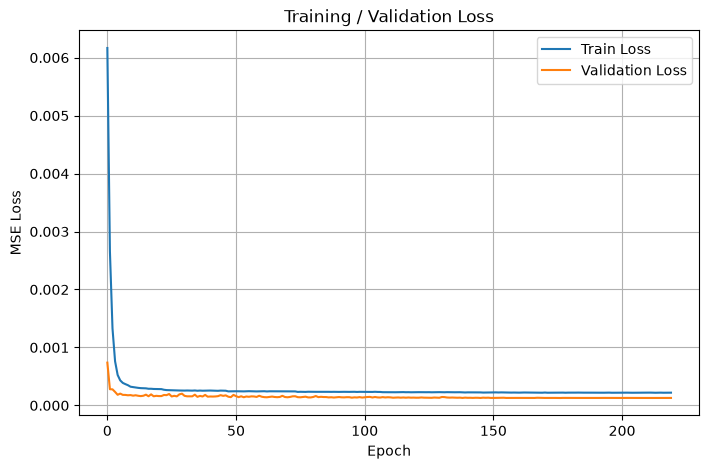

In [20]:
# 16. 학습 곡선

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training / Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

In [21]:
# 17. 30초 단위 recursive 예측 함수

FORECAST_SECONDS_LIST = [30, 60, 300, 600, 900]
MAX_FORECAST_SECONDS = max(FORECAST_SECONDS_LIST)
TOLERANCE_SECONDS = 15


def haversine_km(lat1, lon1, lat2, lon2):
    return haversine_km_np(lat1, lon1, lat2, lon2)


def estimate_sog_cog_from_points(prev_lat, prev_lon, new_lat, new_lon, seconds=30):
    dist_km = haversine_km(prev_lat, prev_lon, new_lat, new_lon)
    sog_knots = (dist_km / 1.852) / (seconds / 3600)

    dlon = np.radians(new_lon - prev_lon)
    lat1 = np.radians(prev_lat)
    lat2 = np.radians(new_lat)

    y = np.sin(dlon) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)

    cog = (np.degrees(np.arctan2(y, x)) + 360) % 360
    return sog_knots, cog


def predict_next_position(model, raw_seq, norm_seq):
    graph = create_multi_graph(raw_seq)

    X = torch.tensor(norm_seq, dtype=torch.float32).unsqueeze(0).to(device)
    graphs = torch.tensor(graph, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_delta_norm = model(X, graphs).cpu().numpy()

    pred_delta = y_scaler.inverse_transform(pred_delta_norm)[0]
    pred_latlon = raw_seq[-1, :2] + pred_delta

    return pred_delta, pred_latlon


def recursive_forecast_path(model, raw_seq, norm_seq, forecast_seconds=900):
    steps = int(forecast_seconds / STEP_SECONDS)

    raw_seq = raw_seq.copy()
    norm_seq = norm_seq.copy()
    predicted_path = []

    for step in range(1, steps + 1):
        pred_delta, pred_latlon = predict_next_position(model, raw_seq, norm_seq)

        prev_raw = raw_seq[-1].copy()
        new_raw = prev_raw.copy()

        new_raw[0] = pred_latlon[0]
        new_raw[1] = pred_latlon[1]

        est_sog, est_cog = estimate_sog_cog_from_points(
            prev_raw[0], prev_raw[1],
            pred_latlon[0], pred_latlon[1],
            seconds=STEP_SECONDS
        )

        new_raw[2] = est_sog
        new_raw[3] = np.sin(np.radians(est_cog))
        new_raw[4] = np.cos(np.radians(est_cog))
        new_raw[5] = np.sin(np.radians(est_cog))
        new_raw[6] = np.cos(np.radians(est_cog))

        new_norm = x_scaler.transform(pd.DataFrame([new_raw], columns=feature_cols))[0]

        raw_seq = np.vstack([raw_seq[1:], new_raw])
        norm_seq = np.vstack([norm_seq[1:], new_norm])

        predicted_path.append({
            "step": step,
            "forecast_seconds": step * STEP_SECONDS,
            "forecast_minutes": step * STEP_SECONDS / 60,
            "lat": pred_latlon[0],
            "lon": pred_latlon[1]
        })

    return pd.DataFrame(predicted_path)


def get_actual_position_near_time(df, mmsi, target_time, tolerance_seconds=15):
    tolerance = pd.Timedelta(seconds=tolerance_seconds)

    vessel_df = df[
        (df["MMSI"] == mmsi) &
        (df["timestamp"] >= target_time - tolerance) &
        (df["timestamp"] <= target_time + tolerance)
    ].copy()

    if len(vessel_df) == 0:
        return None

    vessel_df["time_diff"] = (vessel_df["timestamp"] - target_time).abs()
    row = vessel_df.sort_values("time_diff").iloc[0]

    return {
        "timestamp": row["timestamp"],
        "lat": row["lat"],
        "lon": row["lon"]
    }


def get_actual_path_for_horizons(df, mmsi, base_time, forecast_seconds_list):
    rows = []

    for seconds in forecast_seconds_list:
        actual = get_actual_position_near_time(
            df,
            mmsi,
            base_time + pd.Timedelta(seconds=seconds),
            tolerance_seconds=TOLERANCE_SECONDS
        )

        if actual is None:
            continue

        rows.append({
            "forecast_seconds": seconds,
            "forecast_minutes": seconds / 60,
            "timestamp": actual["timestamp"],
            "lat": actual["lat"],
            "lon": actual["lon"]
        })

    return pd.DataFrame(rows)

In [22]:
# 18. 8월 test 전체 선박 / 전체 가능한 시점 예측

test_trajectory_records = []
test_trajectory_paths = []

total_candidates = 0
used_candidates = 0

model.eval()

for mmsi_idx, (mmsi, raw_group) in enumerate(test_raw.groupby("MMSI"), start=1):
    raw_group = raw_group.sort_values("timestamp").reset_index(drop=True)
    norm_group = test_norm[test_norm["MMSI"] == mmsi].sort_values("timestamp").reset_index(drop=True)

    if len(raw_group) < SEQ_LEN + 1:
        continue

    raw_data = raw_group[feature_cols].values.astype(np.float32)
    norm_data = norm_group[feature_cols].values.astype(np.float32)
    timestamps = raw_group["timestamp"].values.astype("datetime64[ns]")

    for start_idx in range(0, len(raw_group) - SEQ_LEN):
        total_candidates += 1

        time_window = timestamps[start_idx:start_idx + SEQ_LEN]
        time_diffs = np.diff(time_window).astype("timedelta64[s]")

        if not np.all(time_diffs == TARGET_GAP):
            continue

        base_time = pd.Timestamp(timestamps[start_idx + SEQ_LEN - 1])

        raw_seq = raw_data[start_idx:start_idx + SEQ_LEN]
        norm_seq = norm_data[start_idx:start_idx + SEQ_LEN]

        pred_path = recursive_forecast_path(
            model,
            raw_seq,
            norm_seq,
            forecast_seconds=MAX_FORECAST_SECONDS
        )

        actual_path = get_actual_path_for_horizons(
            test_raw,
            mmsi,
            base_time,
            FORECAST_SECONDS_LIST
        )

        if len(actual_path) == 0:
            continue

        pred_horizon = pred_path[
            pred_path["forecast_seconds"].isin(FORECAST_SECONDS_LIST)
        ].copy()

        merged = pred_horizon.merge(
            actual_path,
            on=["forecast_seconds", "forecast_minutes"],
            suffixes=("_pred", "_actual")
        )

        if len(merged) == 0:
            continue

        used_candidates += 1

        for _, row in merged.iterrows():
            error_km = haversine_km(
                row["lat_actual"], row["lon_actual"],
                row["lat_pred"], row["lon_pred"]
            )

            test_trajectory_records.append({
                "base_time": base_time,
                "MMSI": mmsi,
                "start_sog": raw_seq[-1][2],
                "forecast_seconds": row["forecast_seconds"],
                "forecast_minutes": row["forecast_minutes"],
                "pred_lat": row["lat_pred"],
                "pred_lon": row["lon_pred"],
                "actual_lat": row["lat_actual"],
                "actual_lon": row["lon_actual"],
                "error_km": error_km,
                "error_m": error_km * 1000,
                "error_nm": error_km / 1.852
            })

        test_trajectory_paths.append({
            "base_time": base_time,
            "MMSI": mmsi,
            "start_lat": raw_seq[-1][0],
            "start_lon": raw_seq[-1][1],
            "start_sog": raw_seq[-1][2],
            "raw_seq": raw_seq,
            "pred_path": pred_horizon.reset_index(drop=True),
            "actual_path": actual_path.reset_index(drop=True)
        })

    if mmsi_idx % 20 == 0:
        print(f"processed vessels: {mmsi_idx}, total: {total_candidates}, used: {used_candidates}")

test_trajectory_results_df = pd.DataFrame(test_trajectory_records)

print("total candidates:", total_candidates)
print("used candidates:", used_candidates)
print("result rows:", len(test_trajectory_results_df))
print("paths:", len(test_trajectory_paths))

display(test_trajectory_results_df.head())

processed vessels: 20, total: 20077, used: 7330
processed vessels: 40, total: 38086, used: 14488
processed vessels: 60, total: 59030, used: 23384
processed vessels: 80, total: 72123, used: 28294
processed vessels: 100, total: 82104, used: 34243
processed vessels: 120, total: 91227, used: 38786
processed vessels: 140, total: 96686, used: 41667
processed vessels: 160, total: 116175, used: 52398
processed vessels: 180, total: 135203, used: 64593
processed vessels: 200, total: 151541, used: 73175
processed vessels: 220, total: 165669, used: 80380
processed vessels: 240, total: 179014, used: 85119
processed vessels: 260, total: 184600, used: 88436
processed vessels: 280, total: 199522, used: 95627
processed vessels: 300, total: 213379, used: 103249
processed vessels: 320, total: 229208, used: 111165
processed vessels: 340, total: 241352, used: 116054
processed vessels: 360, total: 257744, used: 122688
processed vessels: 380, total: 273108, used: 128863
processed vessels: 400, total: 289775,

,base_time,MMSI,start_sog,forecast_seconds,forecast_minutes,pred_lat,pred_lon,actual_lat,actual_lon,error_km,error_m,error_nm
0,2024-08-05 03:51:30,209079000,11.4,30,0.5,34.982800,128.812851,34.982734,128.812869,0.007491,7.490873,0.004045
1,2024-08-05 03:51:30,209079000,11.4,60,1.0,34.984444,128.812164,34.984274,128.812119,0.019326,19.326320,0.010435
2,2024-08-05 03:51:30,209079000,11.4,300,5.0,34.999184,128.806046,34.997212,128.805584,0.223271,223.270593,0.120556
3,2024-08-05 03:51:30,209079000,11.4,600,10.0,35.018902,128.798141,35.014550,128.798059,0.483959,483.959304,0.261317
4,2024-08-05 03:51:30,209079000,11.4,900,15.0,35.038563,128.790070,35.029171,128.786418,1.095942,1095.941943,0.591761


,forecast_seconds,forecast_minutes,valid_count,vessel_count,mean_error_km,median_error_km,rmse_km,p90_error_km,max_error_km,mean_error_m,median_error_m
0,30,0.5,175423,520,0.006248,0.004101,0.009966,0.012884,0.374310,6.247836,4.101317
1,60,1.0,174010,520,0.011769,0.008261,0.017412,0.024895,0.410905,11.769427,8.261311
2,300,5.0,163607,518,0.132532,0.088336,0.195413,0.302698,2.013390,132.532457,88.336387
3,600,10.0,150297,518,0.422277,0.273138,0.580892,0.960780,4.294851,422.277403,273.138302
4,900,15.0,137647,514,0.784109,0.496607,1.053728,1.771344,7.891770,784.108909,496.607096


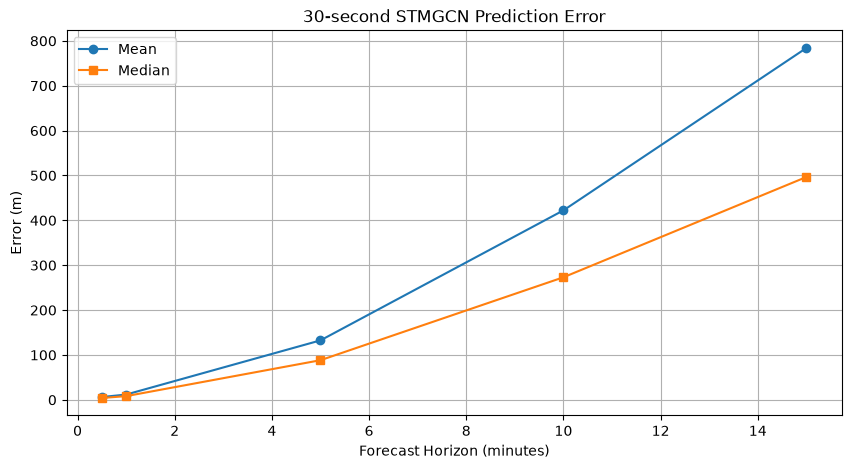

In [23]:
# 19. 성능평가

trajectory_summary_df = (
    test_trajectory_results_df
    .groupby("forecast_seconds")
    .agg(
        forecast_minutes=("forecast_minutes", "first"),
        valid_count=("error_km", "count"),
        vessel_count=("MMSI", "nunique"),
        mean_error_km=("error_km", "mean"),
        median_error_km=("error_km", "median"),
        rmse_km=("error_km", lambda x: np.sqrt(np.mean(np.square(x)))),
        p90_error_km=("error_km", lambda x: np.percentile(x, 90)),
        max_error_km=("error_km", "max"),
        mean_error_m=("error_m", "mean"),
        median_error_m=("error_m", "median")
    )
    .reset_index()
)

display(trajectory_summary_df)

plt.figure(figsize=(10, 5))
plt.plot(trajectory_summary_df["forecast_minutes"], trajectory_summary_df["mean_error_m"], marker="o", label="Mean")
plt.plot(trajectory_summary_df["forecast_minutes"], trajectory_summary_df["median_error_m"], marker="s", label="Median")
plt.xlabel("Forecast Horizon (minutes)")
plt.ylabel("Error (m)")
plt.title("30-second STMGCN Prediction Error")
plt.grid(True)
plt.legend()
plt.show()

horizon counts:


,forecast_seconds,forecast_minutes,row_count,sample_count,vessel_count
0,30,0.5,175423,175423,520
1,60,1.0,174010,174010,520
2,300,5.0,163607,163607,518
3,600,10.0,150297,150297,518
4,900,15.0,137647,137647,514


진짜 상위 5척 MMSI 기준


,mmsi,vessel_mean_error_m,vessel_median_error_m,sample_count,row_count,mean_start_sog
58,248411000,58.367900,3.919003,3716,18580,0.358323
34,228342900,91.666339,6.905360,1741,8705,0.780645
149,352870000,101.338505,28.700191,2434,12170,0.604543
195,371633000,104.817493,27.152941,861,4305,1.079481
477,636020992,105.636942,23.818614,3072,15360,0.463695


그래프에 사용할 각 선박 대표 sample


,mmsi,sample_index,base_time,sample_mean_error_m,vessel_mean_error_m,vessel_median_error_m,sample_count,row_count,mean_start_sog
0,248411000.0,22240,2024-08-16 22:25:00,4.772027,58.367900,3.919003,3716.0,18580.0,0.358323
1,228342900.0,12161,2024-08-09 00:24:30,3.726166,91.666339,6.905360,1741.0,8705.0,0.780645
2,352870000.0,46735,2024-08-23 16:21:00,12.781765,101.338505,28.700191,2434.0,12170.0,0.604543
3,371633000.0,72260,2024-08-31 18:44:00,9.143006,104.817493,27.152941,861.0,4305.0,1.079481
4,636020992.0,165068,2024-08-17 03:55:30,11.957306,105.636942,23.818614,3072.0,15360.0,0.463695


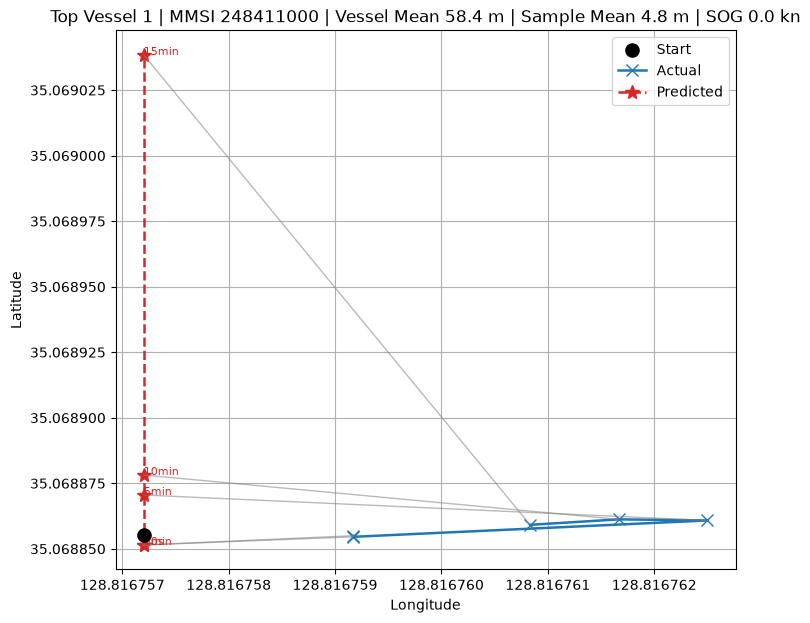

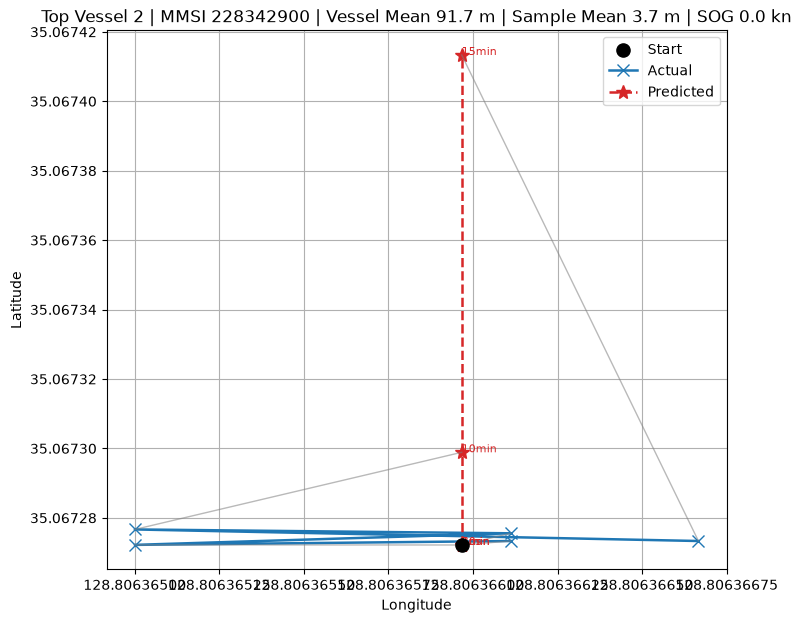

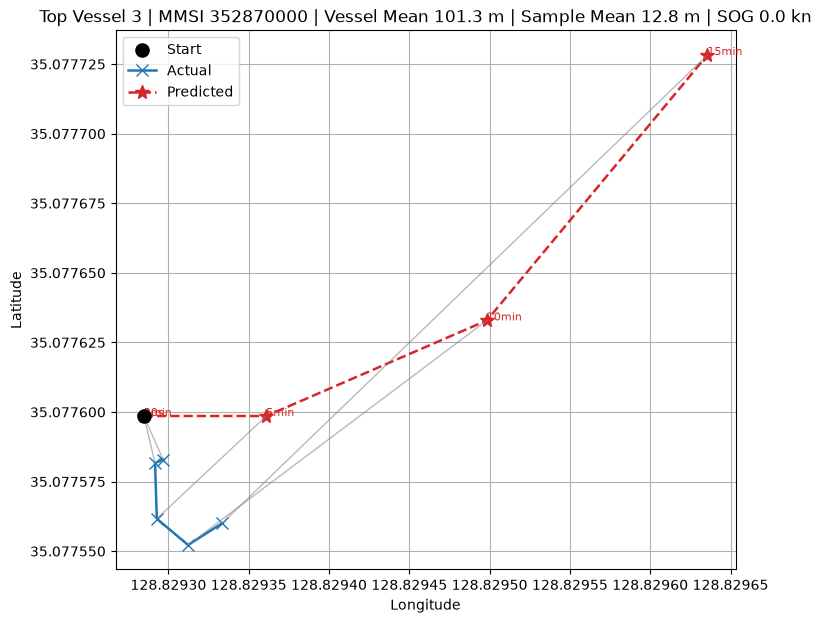

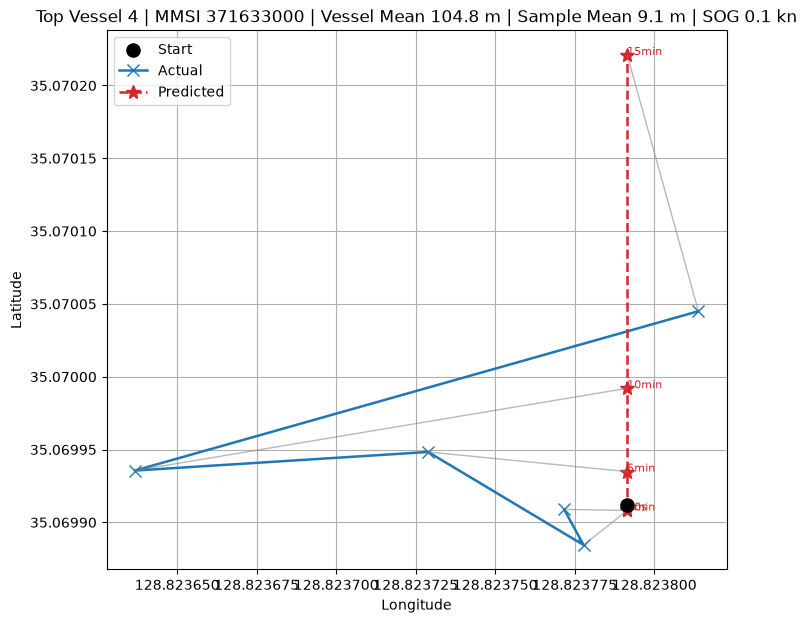

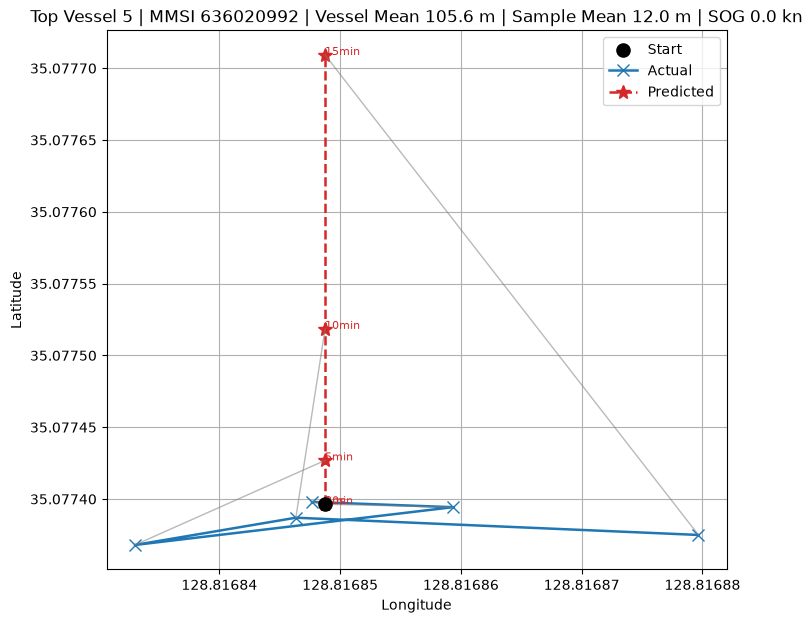

In [25]:
# 20. 예측 정확도 상위 5척 개별 그래프
# 기준: MMSI별 평균 오차
# 각 선박당 대표 sample 1개를 골라 그래프 1개씩 출력

SELECTION_SECONDS = [30, 60, 300, 600, 900]
TOP_N = 5


def build_plot_dataframe(results_df, paths):
    result_df = results_df.copy().rename(columns={
        "MMSI": "mmsi",
        "actual_lat": "true_lat",
        "actual_lon": "true_lon"
    })

    start_rows = []

    for sample_index, item in enumerate(paths):
        start_rows.append({
            "sample_index": sample_index,
            "mmsi": item.get("MMSI"),
            "base_time": item.get("base_time"),
            "last_lat": item.get("start_lat"),
            "last_lon": item.get("start_lon"),
            "path_start_sog": item.get("start_sog", np.nan)
        })

    start_df = pd.DataFrame(start_rows)

    result_df = result_df.merge(
        start_df,
        on=["mmsi", "base_time"],
        how="inner",
        suffixes=("", "_path")
    )

    if "start_sog" not in result_df.columns:
        if "start_sog_x" in result_df.columns:
            result_df["start_sog"] = result_df["start_sog_x"]
        elif "start_sog_y" in result_df.columns:
            result_df["start_sog"] = result_df["start_sog_y"]
        elif "path_start_sog" in result_df.columns:
            result_df["start_sog"] = result_df["path_start_sog"]
        else:
            result_df["start_sog"] = np.nan

    if "path_start_sog" in result_df.columns:
        result_df["start_sog"] = result_df["start_sog"].fillna(result_df["path_start_sog"])

    return result_df.dropna(
        subset=["pred_lat", "pred_lon", "true_lat", "true_lon", "error_m"]
    )


def select_top_vessels(plot_df):
    horizon_df = plot_df[
        plot_df["forecast_seconds"].isin(SELECTION_SECONDS)
    ].copy()

    if len(horizon_df) == 0:
        raise ValueError("선택한 SELECTION_SECONDS에 해당하는 결과가 없습니다.")

    # sample별로 선택 horizon이 모두 있는 것만 사용
    sample_count_df = (
        horizon_df
        .groupby("sample_index")
        .agg(
            mmsi=("mmsi", "first"),
            base_time=("base_time", "first"),
            count=("forecast_seconds", "nunique"),
            sample_mean_error_m=("error_m", "mean")
        )
        .reset_index()
    )

    valid_sample_df = sample_count_df[
        sample_count_df["count"] >= len(SELECTION_SECONDS)
    ].copy()

    if len(valid_sample_df) == 0:
        raise ValueError("선택한 모든 horizon을 가진 sample이 없습니다. SELECTION_SECONDS를 줄여야 합니다.")

    valid_horizon_df = horizon_df[
        horizon_df["sample_index"].isin(valid_sample_df["sample_index"])
    ].copy()

    # 진짜 상위 5척: MMSI별 평균 오차
    vessel_score_df = (
        valid_horizon_df
        .groupby("mmsi")
        .agg(
            vessel_mean_error_m=("error_m", "mean"),
            vessel_median_error_m=("error_m", "median"),
            sample_count=("sample_index", "nunique"),
            row_count=("error_m", "count"),
            mean_start_sog=("start_sog", "mean")
        )
        .reset_index()
        .sort_values("vessel_mean_error_m", ascending=True)
    )

    top_vessels_df = vessel_score_df.head(TOP_N).copy()

    # 각 상위 선박마다 가장 잘 맞은 대표 sample 1개 선택
    representative_rows = []

    for _, vessel_row in top_vessels_df.iterrows():
        mmsi = vessel_row["mmsi"]

        vessel_samples = valid_sample_df[
            valid_sample_df["mmsi"] == mmsi
        ].sort_values("sample_mean_error_m", ascending=True)

        best_sample = vessel_samples.iloc[0].copy()

        representative_rows.append({
            "mmsi": mmsi,
            "sample_index": best_sample["sample_index"],
            "base_time": best_sample["base_time"],
            "sample_mean_error_m": best_sample["sample_mean_error_m"],
            "vessel_mean_error_m": vessel_row["vessel_mean_error_m"],
            "vessel_median_error_m": vessel_row["vessel_median_error_m"],
            "sample_count": vessel_row["sample_count"],
            "row_count": vessel_row["row_count"],
            "mean_start_sog": vessel_row["mean_start_sog"]
        })

    representative_df = pd.DataFrame(representative_rows)

    return vessel_score_df, top_vessels_df, representative_df


def plot_single_top_vessel(plot_df, sample_row, rank):
    sample_index = sample_row["sample_index"]

    group = plot_df[
        (plot_df["sample_index"] == sample_index)
        & (plot_df["forecast_seconds"].isin(SELECTION_SECONDS))
    ].copy()

    group = group.sort_values("forecast_seconds")

    if len(group) == 0:
        return

    mmsi = group.iloc[0]["mmsi"]
    base_time = group.iloc[0]["base_time"]
    start_sog = group.iloc[0]["start_sog"]

    plt.figure(figsize=(8, 7))

    plt.scatter(
        group.iloc[0]["last_lon"],
        group.iloc[0]["last_lat"],
        color="black",
        marker="o",
        s=90,
        label="Start",
        zorder=4
    )

    plt.plot(
        group["true_lon"],
        group["true_lat"],
        color="tab:blue",
        linestyle="-",
        marker="x",
        linewidth=1.8,
        markersize=8,
        label="Actual"
    )

    plt.plot(
        group["pred_lon"],
        group["pred_lat"],
        color="tab:red",
        linestyle="--",
        marker="*",
        linewidth=1.8,
        markersize=10,
        label="Predicted"
    )

    for _, row in group.iterrows():
        plt.plot(
            [row["true_lon"], row["pred_lon"]],
            [row["true_lat"], row["pred_lat"]],
            color="gray",
            alpha=0.55,
            linewidth=1.0
        )

        if row["forecast_seconds"] < 60:
            label = f"{int(row['forecast_seconds'])}s"
        else:
            label = f"{row['forecast_minutes']:.0f}min"

        plt.text(
            row["pred_lon"],
            row["pred_lat"],
            label,
            fontsize=8,
            color="tab:red"
        )

    title = (
        f"Top Vessel {rank} | MMSI {mmsi} | "
        f"Vessel Mean {sample_row['vessel_mean_error_m']:.1f} m | "
        f"Sample Mean {sample_row['sample_mean_error_m']:.1f} m | "
        f"SOG {start_sog:.1f} kn"
    )

    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.legend()

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style="plain", axis="both")

    plt.show()


plot_df = build_plot_dataframe(test_trajectory_results_df, test_trajectory_paths)

print("horizon counts:")
display(
    plot_df
    .groupby("forecast_seconds")
    .agg(
        forecast_minutes=("forecast_minutes", "first"),
        row_count=("error_m", "count"),
        sample_count=("sample_index", "nunique"),
        vessel_count=("mmsi", "nunique")
    )
    .reset_index()
)

vessel_score_df, top_vessels_df, top5_representative_df = select_top_vessels(plot_df)

print("진짜 상위 5척 MMSI 기준")
display(top_vessels_df)

print("그래프에 사용할 각 선박 대표 sample")
display(top5_representative_df)

for rank, (_, row) in enumerate(top5_representative_df.iterrows(), start=1):
    plot_single_top_vessel(plot_df, row, rank)

In [26]:
# A. 30초 one-step 모델/스케일러/그래프 정보/예측결과 저장

import os
import joblib
import torch

SAVE_DIR = "stm_gcn_30s_onestep_artifacts"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. 모델 저장
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_config": {
            "input_dim": len(feature_cols),
            "hidden_dim": 64,
            "num_graphs": 2,
            "output_dim": 2,
            "num_temporal_blocks": 2,
            "dropout": 0.1
        },
        "step_seconds": STEP_SECONDS,
        "seq_len": SEQ_LEN,
        "forecast_seconds_list": FORECAST_SECONDS_LIST,
        "max_forecast_seconds": MAX_FORECAST_SECONDS,
        "tolerance_seconds": TOLERANCE_SECONDS,
        "feature_cols": feature_cols,
        "target_cols": target_cols
    },
    os.path.join(SAVE_DIR, "onestep_model_checkpoint.pt")
)

# 2. scaler 저장
joblib.dump(x_scaler, os.path.join(SAVE_DIR, "x_scaler.pkl"))
joblib.dump(y_scaler, os.path.join(SAVE_DIR, "y_scaler.pkl"))

# 3. graph 생성에 필요한 정보 저장
graph_info = {
    "transition_counts": transition_counts,
    "train_lat_min": train_lat_min,
    "train_lon_min": train_lon_min,
    "TRAIN_GRID_NM": TRAIN_GRID_NM,
    "BASE_LAT_FOR_LON_SCALE": BASE_LAT_FOR_LON_SCALE,
    "TRAIN_LAT_GRID_SIZE": TRAIN_LAT_GRID_SIZE,
    "TRAIN_LON_GRID_SIZE": TRAIN_LON_GRID_SIZE,
    "DISTANCE_GRAPH_SIGMA_KM": DISTANCE_GRAPH_SIGMA_KM
}
joblib.dump(graph_info, os.path.join(SAVE_DIR, "graph_info.pkl"))

# 4. 학습 곡선 저장
history = {
    "train_losses": train_losses if "train_losses" in globals() else None,
    "val_losses": val_losses if "val_losses" in globals() else None,
    "best_val_loss": best_val_loss if "best_val_loss" in globals() else None,
    "full_val_loss": full_val_loss if "full_val_loss" in globals() else None
}
joblib.dump(history, os.path.join(SAVE_DIR, "training_history.pkl"))

# 5. 예측 결과 저장
# 18번 예측을 이미 실행했다면 같이 저장됨
results_bundle = {}

if "test_trajectory_results_df" in globals():
    results_bundle["test_trajectory_results_df"] = test_trajectory_results_df

if "test_trajectory_paths" in globals():
    results_bundle["test_trajectory_paths"] = test_trajectory_paths

if "trajectory_summary_df" in globals():
    results_bundle["trajectory_summary_df"] = trajectory_summary_df

if "plot_df" in globals():
    results_bundle["plot_df"] = plot_df

if "vessel_score_df" in globals():
    results_bundle["vessel_score_df"] = vessel_score_df

if "top_vessels_df" in globals():
    results_bundle["top_vessels_df"] = top_vessels_df

joblib.dump(results_bundle, os.path.join(SAVE_DIR, "prediction_results.pkl"))

print("저장 완료:", SAVE_DIR)
print(os.listdir(SAVE_DIR))

저장 완료: stm_gcn_30s_onestep_artifacts
['graph_info.pkl', 'onestep_model_checkpoint.pt', 'prediction_results.pkl', 'training_history.pkl', 'x_scaler.pkl', 'y_scaler.pkl']


horizon counts:


,forecast_seconds,forecast_minutes,row_count,sample_count,vessel_count,median_error_m,mean_error_m
0,30,0.5,175423,175423,520,4.101317,6.247836
1,60,1.0,174010,174010,520,8.261311,11.769427
2,300,5.0,163607,163607,518,88.336387,132.532457
3,600,10.0,150297,150297,518,273.138302,422.277403
4,900,15.0,137647,137647,514,496.607096,784.108909


단기 예측 기준 상위 5척


,mmsi,vessel_mean_error_m,vessel_median_error_m,vessel_p90_error_m,vessel_max_error_m,sample_count,row_count,mean_start_sog,median_start_sog
89,273298570,17.001544,3.223742,49.372193,696.202497,2304,6912,1.009776,0.000000
189,368680000,25.120633,4.429380,79.874454,577.156562,1059,3177,3.164068,0.066667
426,636012808,21.305003,5.132879,41.034393,760.328748,1484,4452,1.112907,0.100000
118,311922000,64.485305,5.914165,187.595188,896.539827,40,120,13.430096,13.700000
50,232043367,30.377546,6.039305,110.517769,262.878958,143,429,5.382418,6.133333


그래프에 사용할 대표 sample


,mmsi,sample_index,base_time,sample_mean_error_m,sample_median_error_m,sample_max_error_m,vessel_mean_error_m,vessel_median_error_m,vessel_p90_error_m,sample_count,mean_start_sog
0,273298570.0,31582,2024-08-07 22:15:00,0.439595,0.231581,0.889637,17.001544,3.223742,49.372193,2304.0,1.009776
1,368680000.0,67054,2024-08-03 08:37:30,1.885868,0.079979,5.509675,25.120633,4.429380,79.874454,1059.0,3.164068
2,636012808.0,146530,2024-08-14 11:29:30,9.700091,0.144978,28.831167,21.305003,5.132879,41.034393,1484.0,1.112907
3,311922000.0,38570,2024-08-15 19:59:30,3.989567,0.857376,10.430860,64.485305,5.914165,187.595188,40.0,13.430096
4,232043367.0,17841,2024-08-30 16:41:30,18.337687,1.348979,52.508501,30.377546,6.039305,110.517769,143.0,5.382418


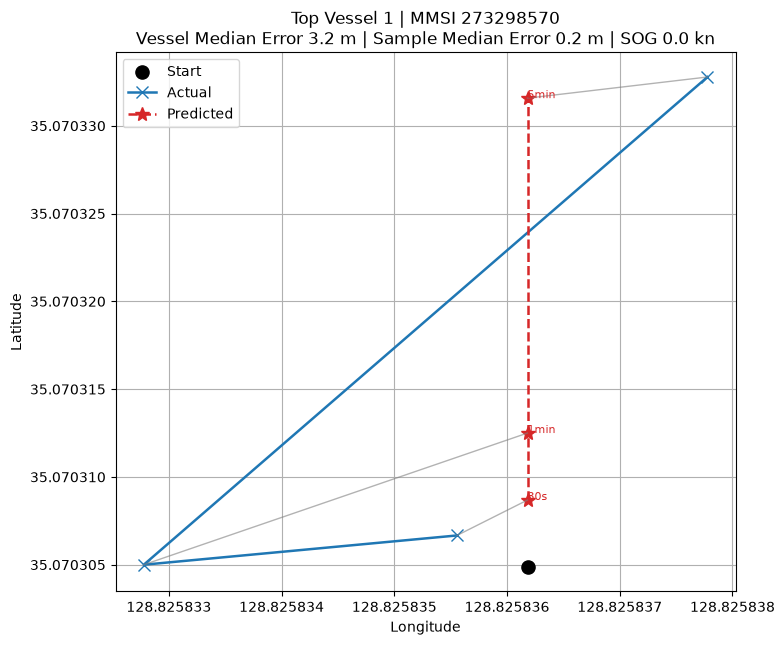

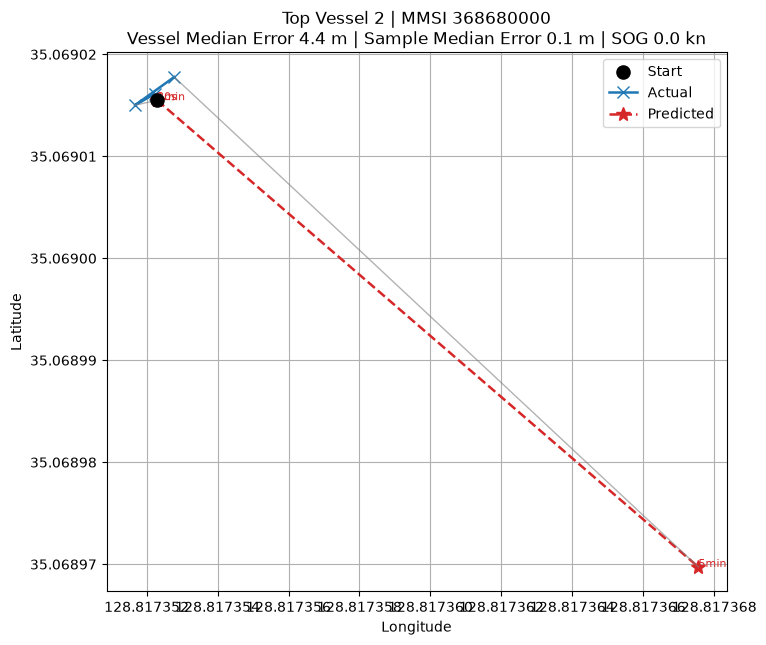

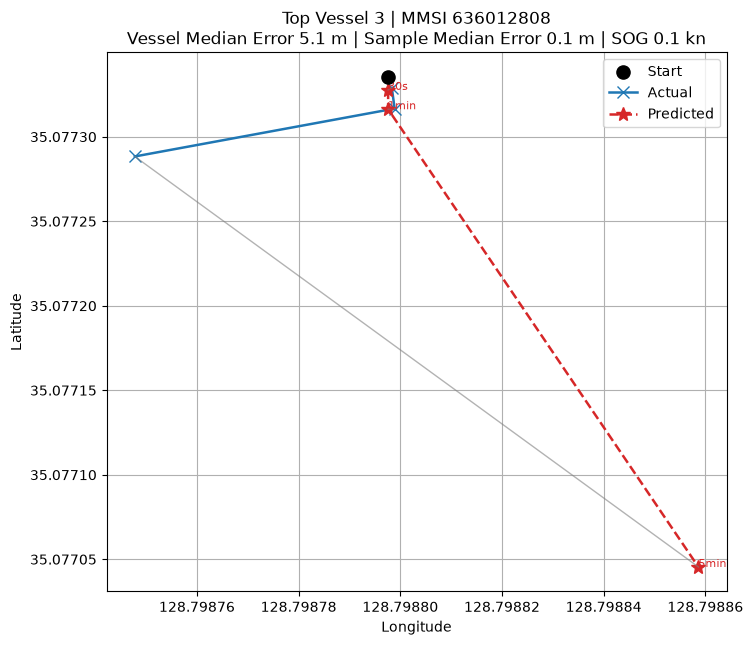

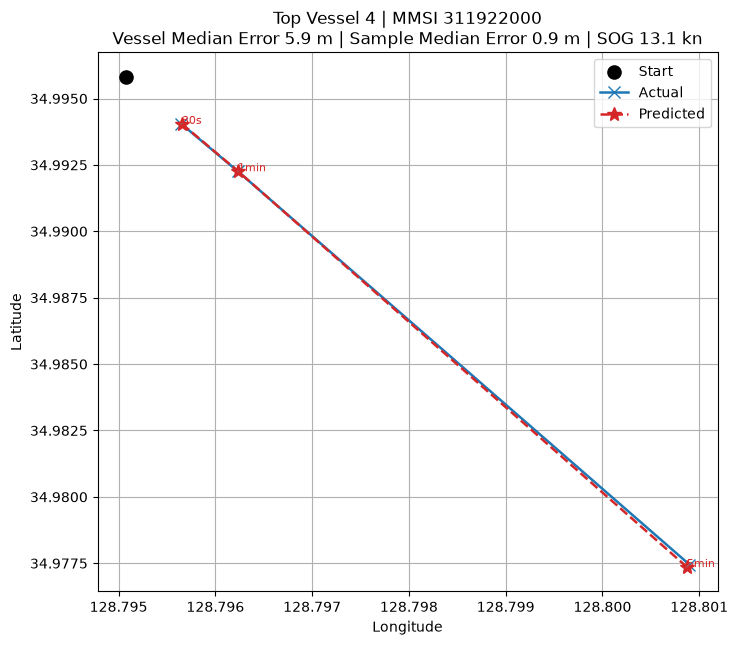

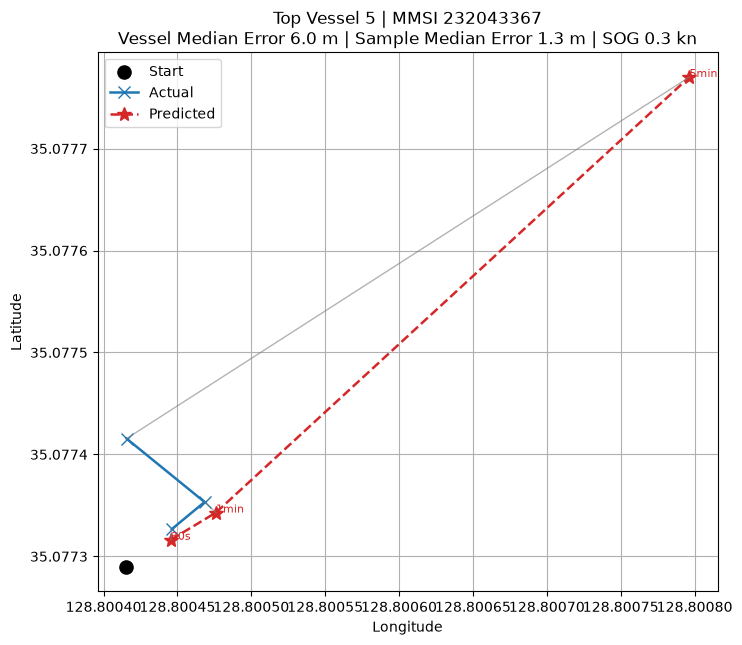

In [29]:
# 20. 단기 예측 기준 상위 5척 개별 그래프
# 기준:
# - horizon: 30초, 1분, 5분
# - MMSI별 median error 기준
# - sample_count >= 5
# - 평균 start_sog >= 1.0 knot
# - 선박 1척당 대표 sample 1개 그래프 출력
# - 예측-실제 연결선 포함

SHORT_SELECTION_SECONDS = [30, 60, 300]
TOP_N = 5
MIN_SAMPLE_COUNT = 5
MIN_MEAN_START_SOG = 1.0
SCORE_COL = "vessel_median_error_m"


def build_plot_dataframe_short(results_df, paths):
    result_df = results_df.copy().rename(columns={
        "MMSI": "mmsi",
        "actual_lat": "true_lat",
        "actual_lon": "true_lon"
    })

    start_rows = []

    for sample_index, item in enumerate(paths):
        start_rows.append({
            "sample_index": sample_index,
            "mmsi": item.get("MMSI"),
            "base_time": item.get("base_time"),
            "last_lat": item.get("start_lat"),
            "last_lon": item.get("start_lon"),
            "path_start_sog": item.get("start_sog", np.nan)
        })

    start_df = pd.DataFrame(start_rows)

    result_df = result_df.merge(
        start_df,
        on=["mmsi", "base_time"],
        how="inner",
        suffixes=("", "_path")
    )

    if "start_sog" not in result_df.columns:
        if "start_sog_x" in result_df.columns:
            result_df["start_sog"] = result_df["start_sog_x"]
        elif "start_sog_y" in result_df.columns:
            result_df["start_sog"] = result_df["start_sog_y"]
        elif "path_start_sog" in result_df.columns:
            result_df["start_sog"] = result_df["path_start_sog"]
        else:
            result_df["start_sog"] = np.nan

    if "path_start_sog" in result_df.columns:
        result_df["start_sog"] = result_df["start_sog"].fillna(result_df["path_start_sog"])

    return result_df.dropna(
        subset=[
            "sample_index",
            "mmsi",
            "base_time",
            "forecast_seconds",
            "pred_lat",
            "pred_lon",
            "true_lat",
            "true_lon",
            "error_m",
            "last_lat",
            "last_lon",
            "start_sog"
        ]
    )


def select_top_vessels_short(plot_df):
    horizon_df = plot_df[
        plot_df["forecast_seconds"].isin(SHORT_SELECTION_SECONDS)
    ].copy()

    if len(horizon_df) == 0:
        raise ValueError("SHORT_SELECTION_SECONDS에 해당하는 결과가 없습니다.")

    sample_score_df = (
        horizon_df
        .groupby("sample_index")
        .agg(
            mmsi=("mmsi", "first"),
            base_time=("base_time", "first"),
            sample_mean_error_m=("error_m", "mean"),
            sample_median_error_m=("error_m", "median"),
            sample_max_error_m=("error_m", "max"),
            sample_start_sog=("start_sog", "first"),
            horizon_count=("forecast_seconds", "nunique")
        )
        .reset_index()
    )

    valid_sample_df = sample_score_df[
        sample_score_df["horizon_count"] >= len(SHORT_SELECTION_SECONDS)
    ].copy()

    if len(valid_sample_df) == 0:
        raise ValueError("30초, 1분, 5분 horizon을 모두 가진 sample이 없습니다.")

    valid_horizon_df = horizon_df[
        horizon_df["sample_index"].isin(valid_sample_df["sample_index"])
    ].copy()

    vessel_score_df = (
        valid_horizon_df
        .groupby("mmsi")
        .agg(
            vessel_mean_error_m=("error_m", "mean"),
            vessel_median_error_m=("error_m", "median"),
            vessel_p90_error_m=("error_m", lambda x: np.percentile(x, 90)),
            vessel_max_error_m=("error_m", "max"),
            sample_count=("sample_index", "nunique"),
            row_count=("error_m", "count"),
            mean_start_sog=("start_sog", "mean"),
            median_start_sog=("start_sog", "median")
        )
        .reset_index()
    )

    vessel_score_df = vessel_score_df[
        (vessel_score_df["sample_count"] >= MIN_SAMPLE_COUNT)
        & (vessel_score_df["mean_start_sog"] >= MIN_MEAN_START_SOG)
    ].copy()

    if len(vessel_score_df) == 0:
        print("주의: 조건을 만족하는 선박이 없습니다. 조건을 완화합니다.")
        print("기존 조건:")
        print("MIN_SAMPLE_COUNT:", MIN_SAMPLE_COUNT)
        print("MIN_MEAN_START_SOG:", MIN_MEAN_START_SOG)

        vessel_score_df = (
            valid_horizon_df
            .groupby("mmsi")
            .agg(
                vessel_mean_error_m=("error_m", "mean"),
                vessel_median_error_m=("error_m", "median"),
                vessel_p90_error_m=("error_m", lambda x: np.percentile(x, 90)),
                vessel_max_error_m=("error_m", "max"),
                sample_count=("sample_index", "nunique"),
                row_count=("error_m", "count"),
                mean_start_sog=("start_sog", "mean"),
                median_start_sog=("start_sog", "median")
            )
            .reset_index()
        )

    vessel_score_df = vessel_score_df.sort_values(SCORE_COL, ascending=True)
    top_vessels_df = vessel_score_df.head(TOP_N).copy()

    representative_rows = []

    for _, vessel_row in top_vessels_df.iterrows():
        mmsi = vessel_row["mmsi"]

        vessel_samples = valid_sample_df[
            valid_sample_df["mmsi"] == mmsi
        ].copy()

        vessel_samples = vessel_samples.sort_values(
            "sample_median_error_m",
            ascending=True
        )

        best_sample = vessel_samples.iloc[0]

        representative_rows.append({
            "mmsi": mmsi,
            "sample_index": best_sample["sample_index"],
            "base_time": best_sample["base_time"],
            "sample_mean_error_m": best_sample["sample_mean_error_m"],
            "sample_median_error_m": best_sample["sample_median_error_m"],
            "sample_max_error_m": best_sample["sample_max_error_m"],
            "vessel_mean_error_m": vessel_row["vessel_mean_error_m"],
            "vessel_median_error_m": vessel_row["vessel_median_error_m"],
            "vessel_p90_error_m": vessel_row["vessel_p90_error_m"],
            "sample_count": vessel_row["sample_count"],
            "mean_start_sog": vessel_row["mean_start_sog"]
        })

    representative_df = pd.DataFrame(representative_rows)

    return vessel_score_df, top_vessels_df, representative_df


def plot_single_top_vessel_short(plot_df, sample_row, rank):
    sample_index = sample_row["sample_index"]

    group = plot_df[
        (plot_df["sample_index"] == sample_index)
        & (plot_df["forecast_seconds"].isin(SHORT_SELECTION_SECONDS))
    ].copy()

    group = group.sort_values("forecast_seconds")

    if len(group) == 0:
        return

    mmsi = group.iloc[0]["mmsi"]
    base_time = group.iloc[0]["base_time"]
    start_sog = group.iloc[0]["start_sog"]

    plt.figure(figsize=(8, 7))

    plt.scatter(
        group.iloc[0]["last_lon"],
        group.iloc[0]["last_lat"],
        color="black",
        marker="o",
        s=90,
        label="Start",
        zorder=4
    )

    plt.plot(
        group["true_lon"],
        group["true_lat"],
        color="tab:blue",
        linestyle="-",
        marker="x",
        linewidth=1.8,
        markersize=8,
        label="Actual"
    )

    plt.plot(
        group["pred_lon"],
        group["pred_lat"],
        color="tab:red",
        linestyle="--",
        marker="*",
        linewidth=1.8,
        markersize=10,
        label="Predicted"
    )

    for _, row in group.iterrows():
        plt.plot(
            [row["true_lon"], row["pred_lon"]],
            [row["true_lat"], row["pred_lat"]],
            color="gray",
            alpha=0.6,
            linewidth=1.0
        )

        if row["forecast_seconds"] < 60:
            label = f"{int(row['forecast_seconds'])}s"
        else:
            label = f"{row['forecast_minutes']:.0f}min"

        plt.text(
            row["pred_lon"],
            row["pred_lat"],
            label,
            fontsize=8,
            color="tab:red"
        )

    title = (
        f"Top Vessel {rank} | MMSI {mmsi}\n"
        f"Vessel Median Error {sample_row['vessel_median_error_m']:.1f} m | "
        f"Sample Median Error {sample_row['sample_median_error_m']:.1f} m | "
        f"SOG {start_sog:.1f} kn"
    )

    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.legend()

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style="plain", axis="both")

    plt.show()


plot_df_short = build_plot_dataframe_short(
    test_trajectory_results_df,
    test_trajectory_paths
)

print("horizon counts:")
display(
    plot_df_short
    .groupby("forecast_seconds")
    .agg(
        forecast_minutes=("forecast_minutes", "first"),
        row_count=("error_m", "count"),
        sample_count=("sample_index", "nunique"),
        vessel_count=("mmsi", "nunique"),
        median_error_m=("error_m", "median"),
        mean_error_m=("error_m", "mean")
    )
    .reset_index()
)

vessel_score_short_df, top_vessels_short_df, top5_representative_short_df = select_top_vessels_short(
    plot_df_short
)

print("단기 예측 기준 상위 5척")
display(top_vessels_short_df)

print("그래프에 사용할 대표 sample")
display(top5_representative_short_df)

for rank, (_, row) in enumerate(top5_representative_short_df.iterrows(), start=1):
    plot_single_top_vessel_short(plot_df_short, row, rank)

Reference rank: 4
Reference sample_index: 38570
Fixed lon width: 0.00669808989774907
Fixed lat height: 0.02121944427490234


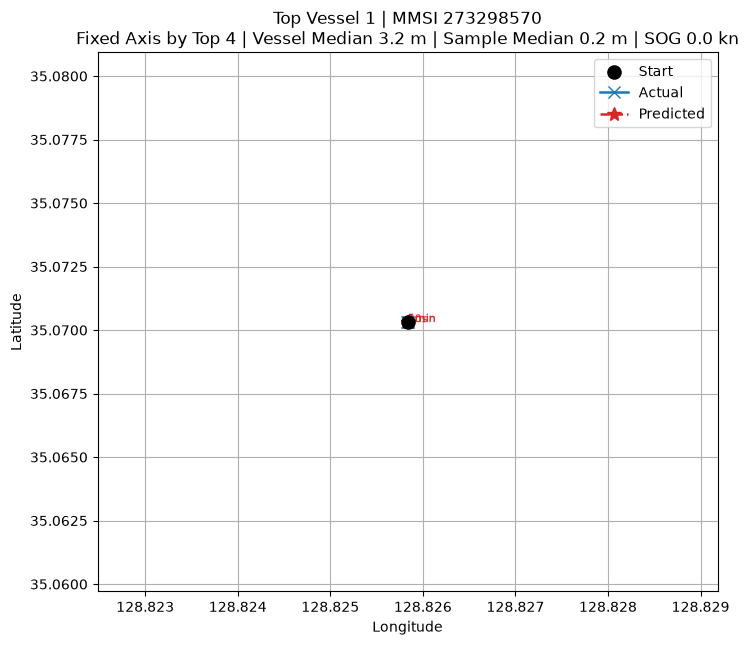

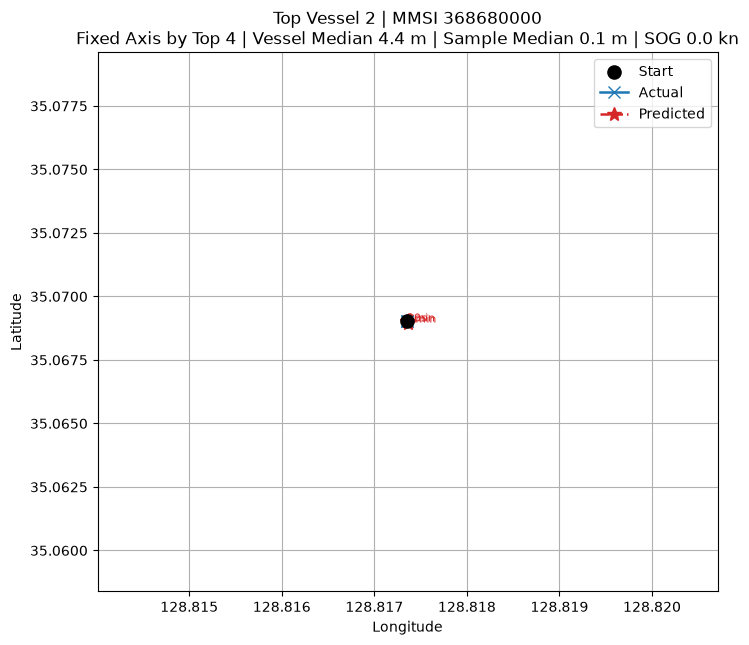

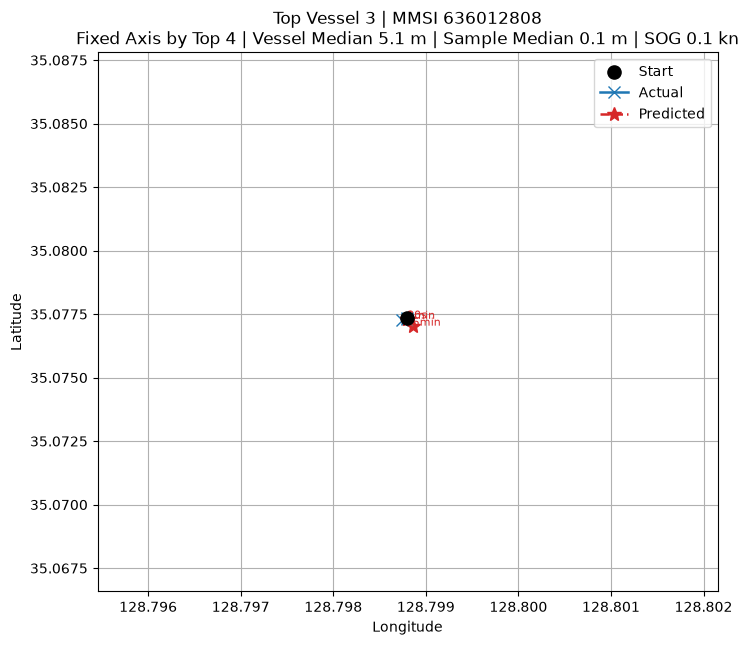

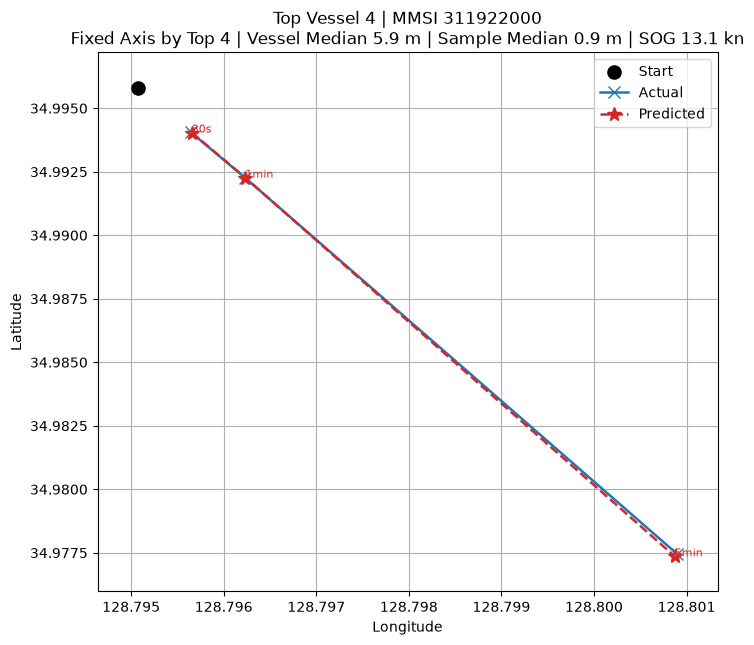

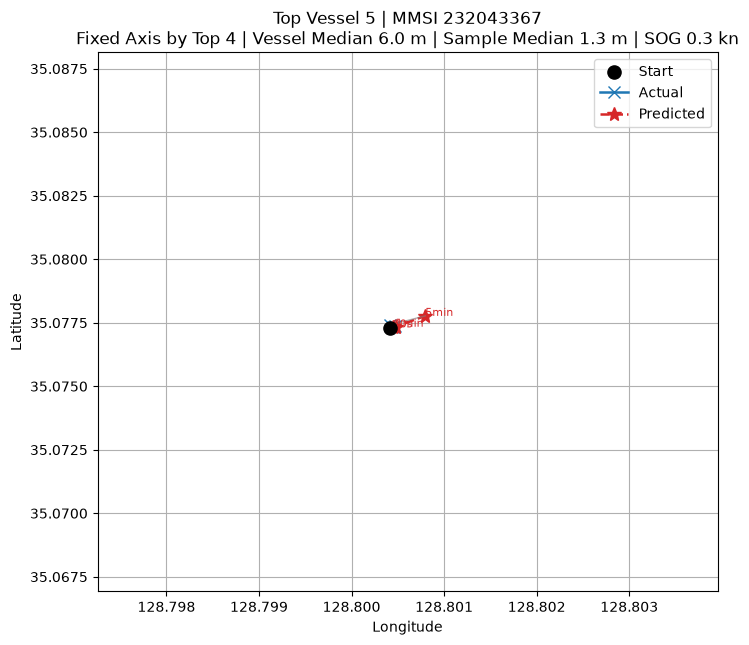

In [30]:
# 20-A. Top4 기준 축 범위 고정 후 상위 5척 재시각화
# 각 선박의 위치 중심은 다르지만, x/y축 표시 길이는 Top4와 동일하게 고정한다.

REFERENCE_RANK = 4


def get_sample_plot_bounds(plot_df, sample_index, selection_seconds):
    group = plot_df[
        (plot_df["sample_index"] == sample_index)
        & (plot_df["forecast_seconds"].isin(selection_seconds))
    ].copy()

    if len(group) == 0:
        raise ValueError("reference sample 데이터가 없습니다.")

    lon_values = np.concatenate([
        group["last_lon"].values,
        group["true_lon"].values,
        group["pred_lon"].values
    ])

    lat_values = np.concatenate([
        group["last_lat"].values,
        group["true_lat"].values,
        group["pred_lat"].values
    ])

    lon_range = lon_values.max() - lon_values.min()
    lat_range = lat_values.max() - lat_values.min()

    # 너무 작은 범위 방지
    lon_range = max(lon_range, 1e-5)
    lat_range = max(lat_range, 1e-5)

    return lon_range, lat_range


def get_group_center(group):
    lon_values = np.concatenate([
        group["last_lon"].values,
        group["true_lon"].values,
        group["pred_lon"].values
    ])

    lat_values = np.concatenate([
        group["last_lat"].values,
        group["true_lat"].values,
        group["pred_lat"].values
    ])

    center_lon = (lon_values.max() + lon_values.min()) / 2
    center_lat = (lat_values.max() + lat_values.min()) / 2

    return center_lon, center_lat


reference_sample_index = top5_representative_short_df.iloc[REFERENCE_RANK - 1]["sample_index"]

ref_lon_range, ref_lat_range = get_sample_plot_bounds(
    plot_df_short,
    reference_sample_index,
    SHORT_SELECTION_SECONDS
)

# 여백 조금 추가
PADDING_RATIO = 0.15
fixed_lon_half = ref_lon_range * (1 + PADDING_RATIO) / 2
fixed_lat_half = ref_lat_range * (1 + PADDING_RATIO) / 2

print("Reference rank:", REFERENCE_RANK)
print("Reference sample_index:", reference_sample_index)
print("Fixed lon width:", fixed_lon_half * 2)
print("Fixed lat height:", fixed_lat_half * 2)


def plot_single_top_vessel_fixed_axis(plot_df, sample_row, rank):
    sample_index = sample_row["sample_index"]

    group = plot_df[
        (plot_df["sample_index"] == sample_index)
        & (plot_df["forecast_seconds"].isin(SHORT_SELECTION_SECONDS))
    ].copy()

    group = group.sort_values("forecast_seconds")

    if len(group) == 0:
        return

    mmsi = group.iloc[0]["mmsi"]
    start_sog = group.iloc[0]["start_sog"]

    center_lon, center_lat = get_group_center(group)

    plt.figure(figsize=(8, 7))

    plt.scatter(
        group.iloc[0]["last_lon"],
        group.iloc[0]["last_lat"],
        color="black",
        marker="o",
        s=90,
        label="Start",
        zorder=4
    )

    plt.plot(
        group["true_lon"],
        group["true_lat"],
        color="tab:blue",
        linestyle="-",
        marker="x",
        linewidth=1.8,
        markersize=8,
        label="Actual"
    )

    plt.plot(
        group["pred_lon"],
        group["pred_lat"],
        color="tab:red",
        linestyle="--",
        marker="*",
        linewidth=1.8,
        markersize=10,
        label="Predicted"
    )

    for _, row in group.iterrows():
        plt.plot(
            [row["true_lon"], row["pred_lon"]],
            [row["true_lat"], row["pred_lat"]],
            color="gray",
            alpha=0.6,
            linewidth=1.0
        )

        if row["forecast_seconds"] < 60:
            label = f"{int(row['forecast_seconds'])}s"
        else:
            label = f"{row['forecast_minutes']:.0f}min"

        plt.text(
            row["pred_lon"],
            row["pred_lat"],
            label,
            fontsize=8,
            color="tab:red"
        )

    plt.xlim(center_lon - fixed_lon_half, center_lon + fixed_lon_half)
    plt.ylim(center_lat - fixed_lat_half, center_lat + fixed_lat_half)

    title = (
        f"Top Vessel {rank} | MMSI {mmsi}\n"
        f"Fixed Axis by Top {REFERENCE_RANK} | "
        f"Vessel Median {sample_row['vessel_median_error_m']:.1f} m | "
        f"Sample Median {sample_row['sample_median_error_m']:.1f} m | "
        f"SOG {start_sog:.1f} kn"
    )

    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.legend()

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style="plain", axis="both")

    plt.show()


for rank, (_, row) in enumerate(top5_representative_short_df.iterrows(), start=1):
    plot_single_top_vessel_fixed_axis(plot_df_short, row, rank)

5분 실제 이동거리 요약:


count    163607.000000
mean        868.113072
std         725.419708
min           0.003701
25%          17.880134
50%         998.098722
75%        1509.503854
max        2852.097107
Name: actual_move_5min_m, dtype: float64

50m 이상 이동 sample 수:


,sample_index,mmsi,actual_move_5min_m
2,0,209079000,1918.543945
7,1,209079000,1944.596678
12,2,209079000,1961.421747
17,3,209079000,1970.987618
22,4,209079000,1989.029015


horizon counts after moving filter:


,forecast_seconds,forecast_minutes,row_count,sample_count,vessel_count,median_error_m,mean_error_m
0,30,0.5,117445,117445,518,4.702583,6.856211
1,60,1.0,117425,117425,518,10.142853,13.615502
2,300,5.0,117488,117488,518,131.734728,173.184265
3,600,10.0,106830,106830,518,429.790489,538.432701
4,900,15.0,95340,95340,514,811.095294,996.208895


5분 실제 이동거리 50m 이상 기준 상위 5척


,mmsi,vessel_mean_error_m,vessel_median_error_m,vessel_p90_error_m,vessel_max_error_m,sample_count,row_count,mean_actual_move_5min_m,median_actual_move_5min_m,mean_start_sog
121,312200000,246.913287,12.264028,1098.490837,2038.506960,34,136,1419.288134,1448.143187,9.073529
344,538004065,254.965530,12.394347,1091.489140,1812.972400,20,80,1209.933683,1074.384438,7.568334
331,477735800,172.958294,15.505410,633.715454,1438.300005,26,104,867.540097,863.053851,5.725641
420,567582000,288.397024,15.710684,1214.832081,2042.094717,36,144,1343.878605,1356.918354,8.289815
353,538007592,243.350931,15.939642,777.562515,1753.736157,28,112,1616.396435,1625.085167,9.504762


그래프에 사용할 대표 sample


,mmsi,sample_index,base_time,actual_move_5min_m,sample_mean_error_m,sample_median_error_m,sample_max_error_m,vessel_mean_error_m,vessel_median_error_m,vessel_p90_error_m,sample_count,mean_actual_move_5min_m,mean_start_sog
0,312200000.0,39215,2024-08-30 19:04:30,1347.524004,45.531319,3.300270,173.045157,246.913287,12.264028,1098.490837,34.0,1419.288134,9.073529
1,538004065.0,119756,2024-08-30 07:27:30,1083.770106,129.665565,8.062389,501.266761,254.965530,12.394347,1091.489140,20.0,1209.933683,7.568334
2,477735800.0,115680,2024-08-03 20:40:00,847.186727,150.637622,7.663063,584.583972,172.958294,15.505410,633.715454,26.0,867.540097,5.725641
3,567582000.0,145185,2024-08-07 05:45:00,1149.804158,173.863418,5.089037,682.844773,288.397024,15.710684,1214.832081,36.0,1343.878605,8.289815
4,538007592.0,122658,2024-08-24 18:09:30,1698.889781,155.948011,11.929537,592.653688,243.350931,15.939642,777.562515,28.0,1616.396435,9.504762


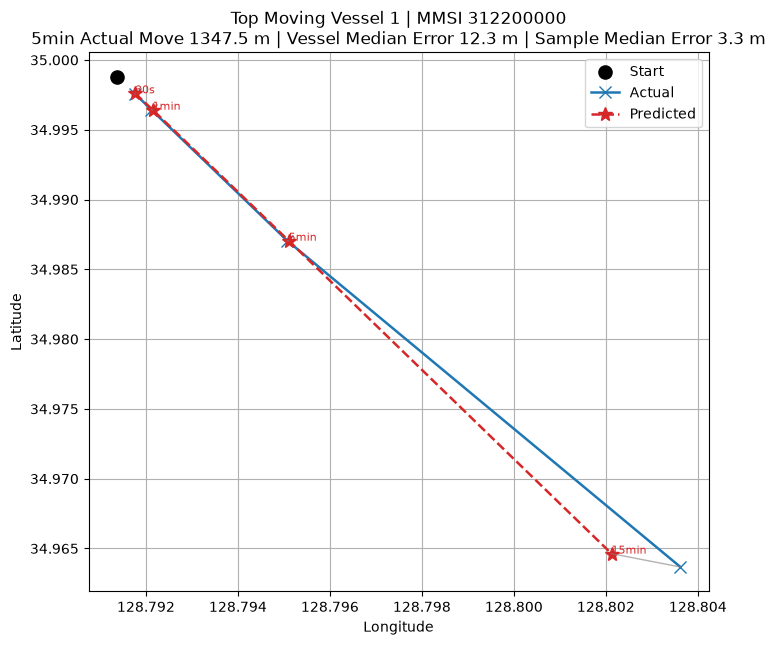

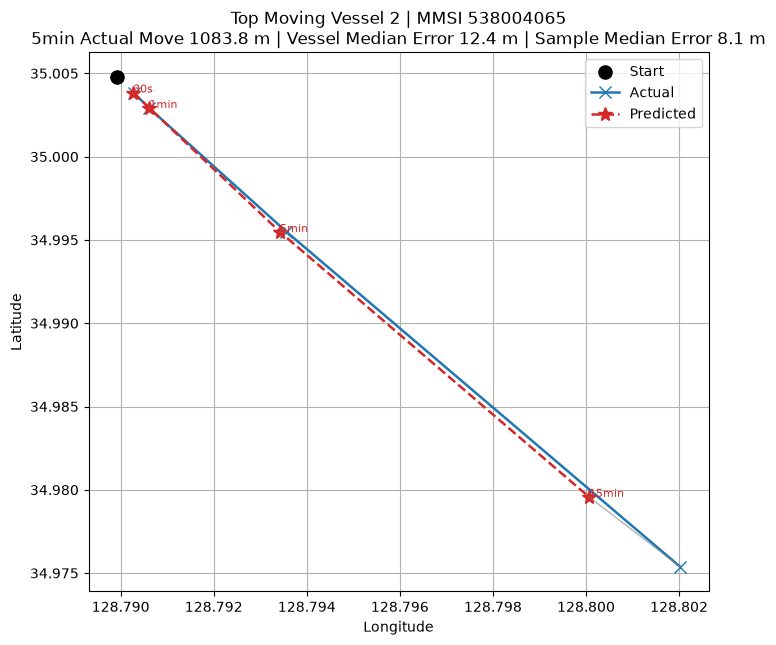

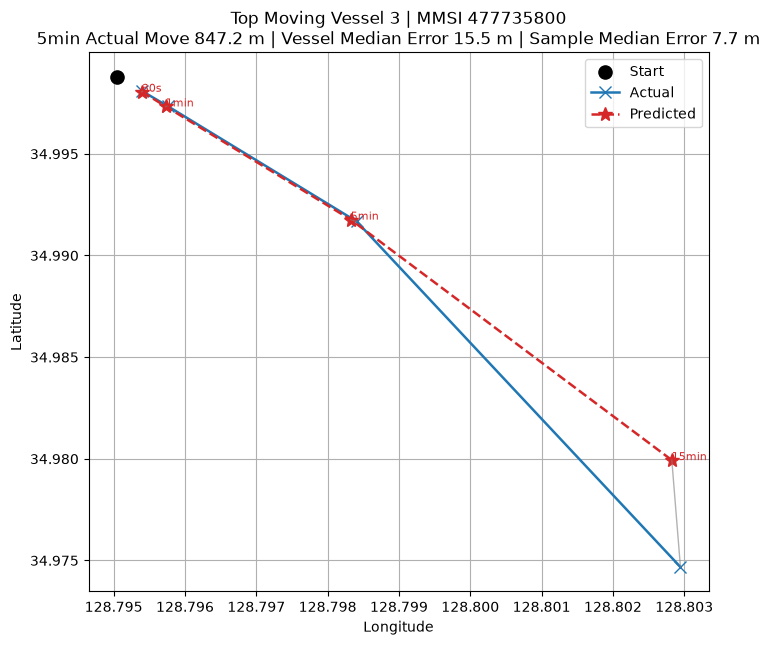

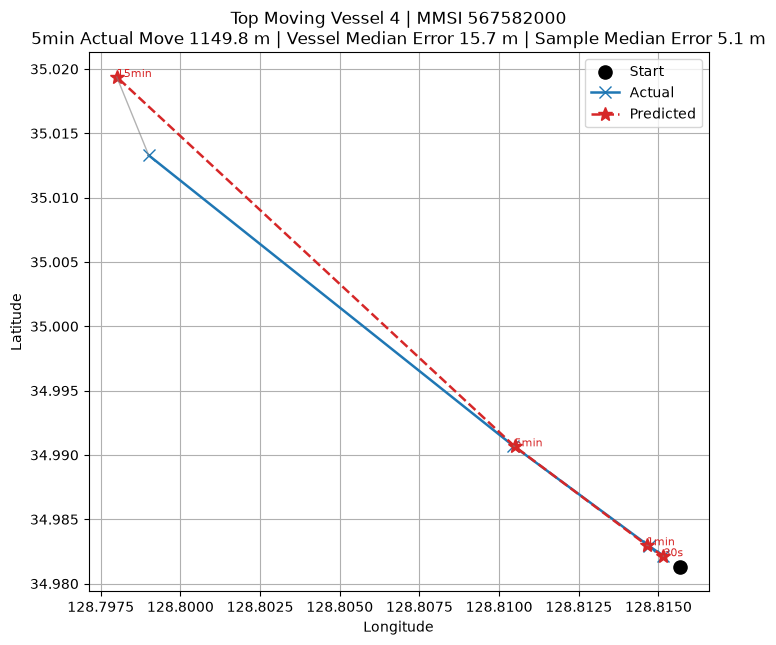

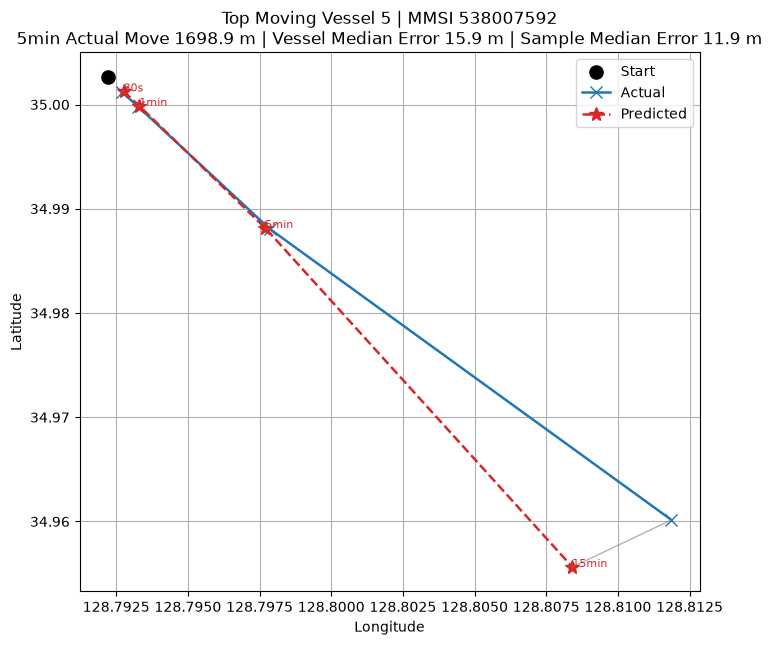

In [32]:
# 20. 실제 5분 이동거리 50m 이상 선박 기준 상위 5척 그래프
# 기준:
# - horizon: 30초, 1분, 5분
# - 5분 실제 이동거리 >= 50m인 sample만 사용
# - MMSI별 median error 기준 상위 5척
# - 선박 1척당 대표 sample 1개 그래프 출력
# - 예측-실제 연결선 포함

SHORT_SELECTION_SECONDS = [30, 60, 300, 900]
TOP_N = 5
MIN_SAMPLE_COUNT = 5
MIN_ACTUAL_MOVE_5MIN_M = 50
SCORE_COL = "vessel_median_error_m"


def build_plot_dataframe_moving(results_df, paths):
    result_df = results_df.copy().rename(columns={
        "MMSI": "mmsi",
        "actual_lat": "true_lat",
        "actual_lon": "true_lon"
    })

    start_rows = []

    for sample_index, item in enumerate(paths):
        start_rows.append({
            "sample_index": sample_index,
            "mmsi": item.get("MMSI"),
            "base_time": item.get("base_time"),
            "last_lat": item.get("start_lat"),
            "last_lon": item.get("start_lon"),
            "path_start_sog": item.get("start_sog", np.nan)
        })

    start_df = pd.DataFrame(start_rows)

    result_df = result_df.merge(
        start_df,
        on=["mmsi", "base_time"],
        how="inner",
        suffixes=("", "_path")
    )

    if "start_sog" not in result_df.columns:
        if "start_sog_x" in result_df.columns:
            result_df["start_sog"] = result_df["start_sog_x"]
        elif "start_sog_y" in result_df.columns:
            result_df["start_sog"] = result_df["start_sog_y"]
        elif "path_start_sog" in result_df.columns:
            result_df["start_sog"] = result_df["path_start_sog"]
        else:
            result_df["start_sog"] = np.nan

    if "path_start_sog" in result_df.columns:
        result_df["start_sog"] = result_df["start_sog"].fillna(result_df["path_start_sog"])

    return result_df.dropna(
        subset=[
            "sample_index",
            "mmsi",
            "base_time",
            "forecast_seconds",
            "pred_lat",
            "pred_lon",
            "true_lat",
            "true_lon",
            "error_m",
            "last_lat",
            "last_lon"
        ]
    )


def add_actual_move_distance(plot_df):
    df = plot_df.copy()

    move_5min_df = df[df["forecast_seconds"] == 300].copy()

    move_5min_df["actual_move_5min_m"] = haversine_km(
        move_5min_df["last_lat"],
        move_5min_df["last_lon"],
        move_5min_df["true_lat"],
        move_5min_df["true_lon"]
    ) * 1000

    move_5min_df = move_5min_df[[
        "sample_index",
        "actual_move_5min_m"
    ]]

    df = df.merge(
        move_5min_df,
        on="sample_index",
        how="left"
    )

    return df


def select_top_vessels_moving(plot_df):
    horizon_df = plot_df[
        plot_df["forecast_seconds"].isin(SHORT_SELECTION_SECONDS)
    ].copy()

    if len(horizon_df) == 0:
        raise ValueError("SHORT_SELECTION_SECONDS에 해당하는 결과가 없습니다.")

    horizon_df = horizon_df[
        horizon_df["actual_move_5min_m"] >= MIN_ACTUAL_MOVE_5MIN_M
    ].copy()

    if len(horizon_df) == 0:
        raise ValueError("5분 실제 이동거리 50m 이상인 sample이 없습니다.")

    sample_score_df = (
        horizon_df
        .groupby("sample_index")
        .agg(
            mmsi=("mmsi", "first"),
            base_time=("base_time", "first"),
            actual_move_5min_m=("actual_move_5min_m", "first"),
            sample_mean_error_m=("error_m", "mean"),
            sample_median_error_m=("error_m", "median"),
            sample_max_error_m=("error_m", "max"),
            sample_start_sog=("start_sog", "first"),
            horizon_count=("forecast_seconds", "nunique")
        )
        .reset_index()
    )

    valid_sample_df = sample_score_df[
        sample_score_df["horizon_count"] >= len(SHORT_SELECTION_SECONDS)
    ].copy()

    if len(valid_sample_df) == 0:
        raise ValueError("30초, 1분, 5분 horizon을 모두 가진 moving sample이 없습니다.")

    valid_horizon_df = horizon_df[
        horizon_df["sample_index"].isin(valid_sample_df["sample_index"])
    ].copy()

    vessel_score_df = (
        valid_horizon_df
        .groupby("mmsi")
        .agg(
            vessel_mean_error_m=("error_m", "mean"),
            vessel_median_error_m=("error_m", "median"),
            vessel_p90_error_m=("error_m", lambda x: np.percentile(x, 90)),
            vessel_max_error_m=("error_m", "max"),
            sample_count=("sample_index", "nunique"),
            row_count=("error_m", "count"),
            mean_actual_move_5min_m=("actual_move_5min_m", "mean"),
            median_actual_move_5min_m=("actual_move_5min_m", "median"),
            mean_start_sog=("start_sog", "mean")
        )
        .reset_index()
    )

    vessel_score_df = vessel_score_df[
        vessel_score_df["sample_count"] >= MIN_SAMPLE_COUNT
    ].copy()

    if len(vessel_score_df) == 0:
        print("주의: sample_count 조건을 만족하는 선박이 없습니다.")
        print("MIN_SAMPLE_COUNT 조건을 완화합니다.")

        vessel_score_df = (
            valid_horizon_df
            .groupby("mmsi")
            .agg(
                vessel_mean_error_m=("error_m", "mean"),
                vessel_median_error_m=("error_m", "median"),
                vessel_p90_error_m=("error_m", lambda x: np.percentile(x, 90)),
                vessel_max_error_m=("error_m", "max"),
                sample_count=("sample_index", "nunique"),
                row_count=("error_m", "count"),
                mean_actual_move_5min_m=("actual_move_5min_m", "mean"),
                median_actual_move_5min_m=("actual_move_5min_m", "median"),
                mean_start_sog=("start_sog", "mean")
            )
            .reset_index()
        )

    vessel_score_df = vessel_score_df.sort_values(SCORE_COL, ascending=True)
    top_vessels_df = vessel_score_df.head(TOP_N).copy()

    representative_rows = []

    for _, vessel_row in top_vessels_df.iterrows():
        mmsi = vessel_row["mmsi"]

        vessel_samples = valid_sample_df[
            valid_sample_df["mmsi"] == mmsi
        ].copy()

        vessel_samples = vessel_samples.sort_values(
            "sample_median_error_m",
            ascending=True
        )

        best_sample = vessel_samples.iloc[0]

        representative_rows.append({
            "mmsi": mmsi,
            "sample_index": best_sample["sample_index"],
            "base_time": best_sample["base_time"],
            "actual_move_5min_m": best_sample["actual_move_5min_m"],
            "sample_mean_error_m": best_sample["sample_mean_error_m"],
            "sample_median_error_m": best_sample["sample_median_error_m"],
            "sample_max_error_m": best_sample["sample_max_error_m"],
            "vessel_mean_error_m": vessel_row["vessel_mean_error_m"],
            "vessel_median_error_m": vessel_row["vessel_median_error_m"],
            "vessel_p90_error_m": vessel_row["vessel_p90_error_m"],
            "sample_count": vessel_row["sample_count"],
            "mean_actual_move_5min_m": vessel_row["mean_actual_move_5min_m"],
            "mean_start_sog": vessel_row["mean_start_sog"]
        })

    representative_df = pd.DataFrame(representative_rows)

    return vessel_score_df, top_vessels_df, representative_df


def plot_single_top_vessel_moving(plot_df, sample_row, rank):
    sample_index = sample_row["sample_index"]

    group = plot_df[
        (plot_df["sample_index"] == sample_index)
        & (plot_df["forecast_seconds"].isin(SHORT_SELECTION_SECONDS))
    ].copy()

    group = group.sort_values("forecast_seconds")

    if len(group) == 0:
        return

    mmsi = group.iloc[0]["mmsi"]
    start_sog = group.iloc[0]["start_sog"]

    plt.figure(figsize=(8, 7))

    plt.scatter(
        group.iloc[0]["last_lon"],
        group.iloc[0]["last_lat"],
        color="black",
        marker="o",
        s=90,
        label="Start",
        zorder=4
    )

    plt.plot(
        group["true_lon"],
        group["true_lat"],
        color="tab:blue",
        linestyle="-",
        marker="x",
        linewidth=1.8,
        markersize=8,
        label="Actual"
    )

    plt.plot(
        group["pred_lon"],
        group["pred_lat"],
        color="tab:red",
        linestyle="--",
        marker="*",
        linewidth=1.8,
        markersize=10,
        label="Predicted"
    )

    for _, row in group.iterrows():
        plt.plot(
            [row["true_lon"], row["pred_lon"]],
            [row["true_lat"], row["pred_lat"]],
            color="gray",
            alpha=0.6,
            linewidth=1.0
        )

        if row["forecast_seconds"] < 60:
            label = f"{int(row['forecast_seconds'])}s"
        else:
            label = f"{row['forecast_minutes']:.0f}min"

        plt.text(
            row["pred_lon"],
            row["pred_lat"],
            label,
            fontsize=8,
            color="tab:red"
        )

    title = (
        f"Top Moving Vessel {rank} | MMSI {mmsi}\n"
        f"5min Actual Move {sample_row['actual_move_5min_m']:.1f} m | "
        f"Vessel Median Error {sample_row['vessel_median_error_m']:.1f} m | "
        f"Sample Median Error {sample_row['sample_median_error_m']:.1f} m"
    )

    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.legend()

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style="plain", axis="both")

    plt.show()


plot_df_moving = build_plot_dataframe_moving(
    test_trajectory_results_df,
    test_trajectory_paths
)

plot_df_moving = add_actual_move_distance(plot_df_moving)

print("5분 실제 이동거리 요약:")
display(
    plot_df_moving[plot_df_moving["forecast_seconds"] == 300]["actual_move_5min_m"]
    .describe()
)

print("50m 이상 이동 sample 수:")
display(
    plot_df_moving[
        (plot_df_moving["forecast_seconds"] == 300)
        & (plot_df_moving["actual_move_5min_m"] >= MIN_ACTUAL_MOVE_5MIN_M)
    ][["sample_index", "mmsi", "actual_move_5min_m"]]
    .drop_duplicates()
    .head()
)

print("horizon counts after moving filter:")
display(
    plot_df_moving[
        plot_df_moving["actual_move_5min_m"] >= MIN_ACTUAL_MOVE_5MIN_M
    ]
    .groupby("forecast_seconds")
    .agg(
        forecast_minutes=("forecast_minutes", "first"),
        row_count=("error_m", "count"),
        sample_count=("sample_index", "nunique"),
        vessel_count=("mmsi", "nunique"),
        median_error_m=("error_m", "median"),
        mean_error_m=("error_m", "mean")
    )
    .reset_index()
)

vessel_score_moving_df, top_vessels_moving_df, top5_representative_moving_df = select_top_vessels_moving(
    plot_df_moving
)

print("5분 실제 이동거리 50m 이상 기준 상위 5척")
display(top_vessels_moving_df)

print("그래프에 사용할 대표 sample")
display(top5_representative_moving_df)

for rank, (_, row) in enumerate(top5_representative_moving_df.iterrows(), start=1):
    plot_single_top_vessel_moving(plot_df_moving, row, rank)

5분 실제 이동거리 요약:


count    163607.000000
mean        868.113072
std         725.419708
min           0.003701
25%          17.880134
50%         998.098722
75%        1509.503854
max        2852.097107
Name: actual_move_5min_m, dtype: float64

50m 이상 이동 sample 수:


,sample_index,mmsi,actual_move_5min_m
2,0,209079000,1918.543945
7,1,209079000,1944.596678
12,2,209079000,1961.421747
17,3,209079000,1970.987618
22,4,209079000,1989.029015


horizon counts after moving filter:


,forecast_seconds,forecast_minutes,row_count,sample_count,vessel_count,median_error_m,mean_error_m
0,30,0.5,117445,117445,518,4.702583,6.856211
1,60,1.0,117425,117425,518,10.142853,13.615502
2,300,5.0,117488,117488,518,131.734728,173.184265
3,600,10.0,106830,106830,518,429.790489,538.432701
4,900,15.0,95340,95340,514,811.095294,996.208895


5분 실제 이동거리 50m 이상 기준 상위 5척


,mmsi,vessel_mean_error_m,vessel_median_error_m,vessel_p90_error_m,vessel_max_error_m,sample_count,row_count,mean_actual_move_5min_m,median_actual_move_5min_m,mean_start_sog
118,311922000,64.485305,5.914165,187.595188,896.539827,40,120,2121.175809,2134.914189,13.430096
123,312200000,50.474195,6.285331,148.070736,767.836131,74,222,1417.530420,1435.342789,9.092085
50,232043367,32.151092,6.291346,119.391766,262.878958,127,381,899.294920,995.247037,6.032696
310,441960000,49.156739,6.838849,120.592876,780.794028,89,267,1506.955603,1494.580543,9.856212
411,565819000,36.515881,6.919038,111.442109,422.402274,205,615,1073.541740,1254.209255,7.058008


그래프에 사용할 대표 sample


,mmsi,sample_index,base_time,actual_move_5min_m,sample_mean_error_m,sample_median_error_m,sample_max_error_m,vessel_mean_error_m,vessel_median_error_m,vessel_p90_error_m,sample_count,mean_actual_move_5min_m,mean_start_sog
0,311922000.0,38570,2024-08-15 19:59:30,2109.204701,3.989567,0.857376,10.430860,64.485305,5.914165,187.595188,40.0,2121.175809,13.430096
1,312200000.0,39209,2024-08-30 19:01:30,1353.394246,7.140029,1.096068,19.931673,50.474195,6.285331,148.070736,74.0,1417.530420,9.092085
2,232043367.0,17801,2024-08-30 16:21:30,419.017212,24.504833,1.407481,71.104928,32.151092,6.291346,119.391766,127.0,899.294920,6.032696
3,441960000.0,108979,2024-08-01 01:01:00,1607.702684,22.701156,1.132068,65.945707,49.156739,6.838849,120.592876,89.0,1506.955603,9.856212
4,565819000.0,140200,2024-08-05 05:55:00,1408.387930,10.748769,1.299635,29.936471,36.515881,6.919038,111.442109,205.0,1073.541740,7.058008


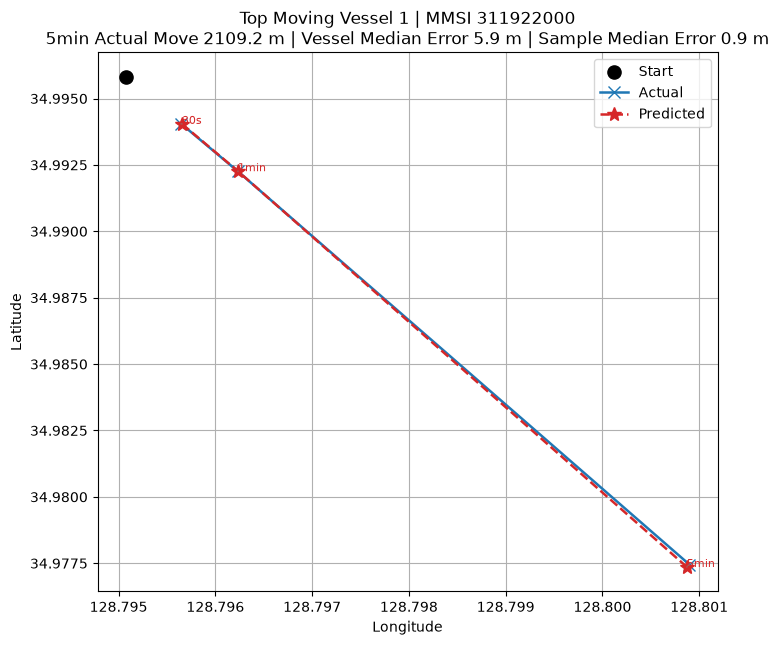

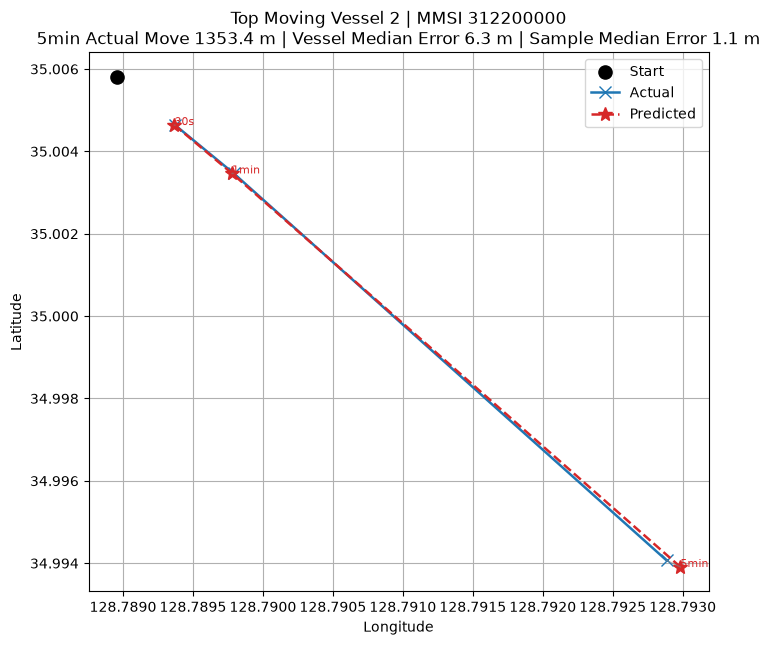

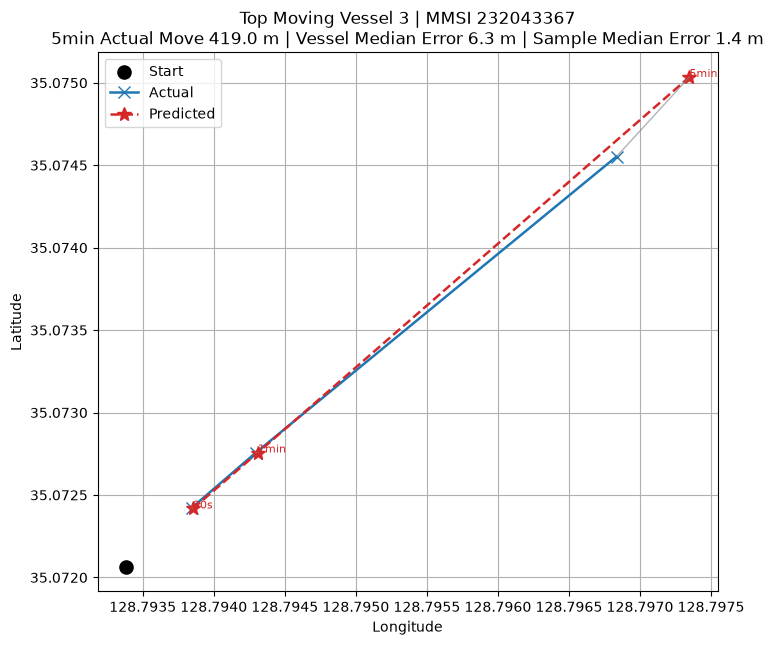

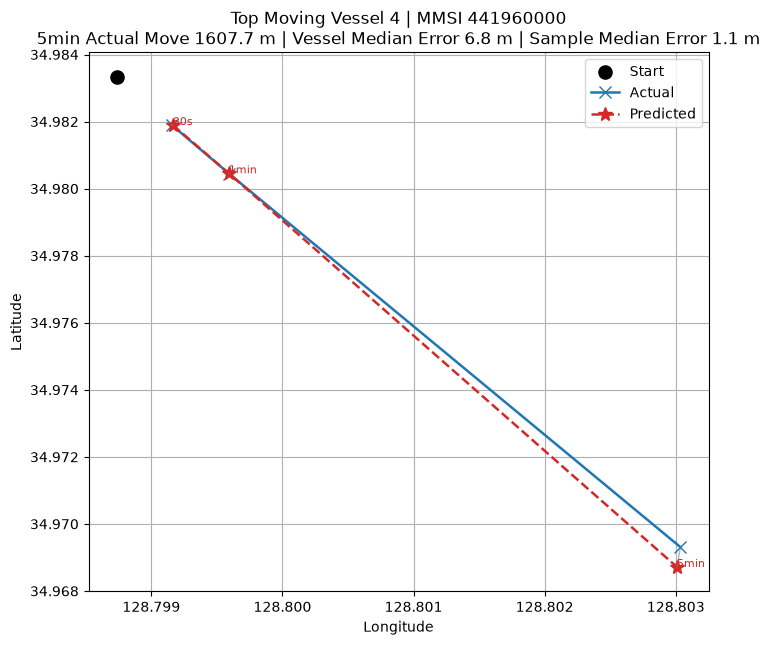

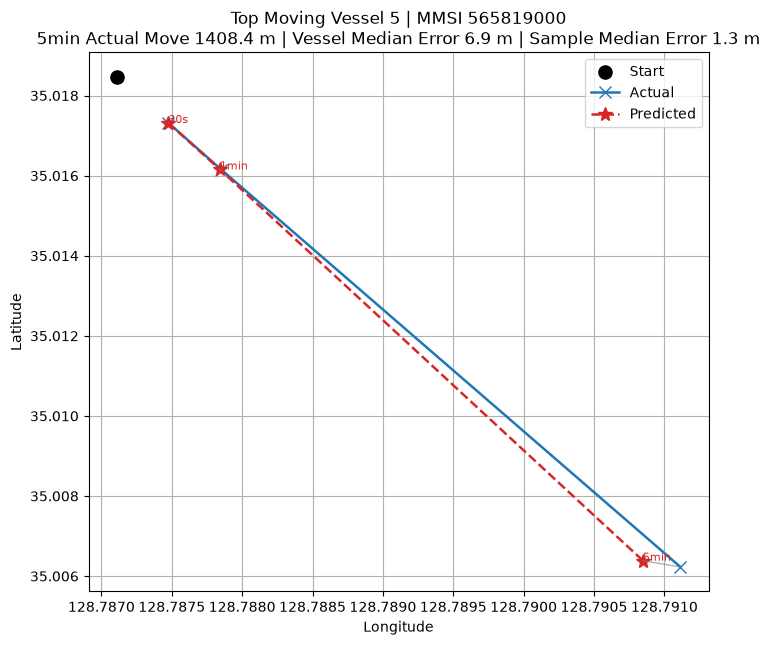

In [33]:
# 20. 실제 5분 이동거리 50m 이상 선박 기준 상위 5척 그래프
# 기준:
# - horizon: 30초, 1분, 5분
# - 5분 실제 이동거리 >= 50m인 sample만 사용
# - MMSI별 median error 기준 상위 5척
# - 선박 1척당 대표 sample 1개 그래프 출력
# - 예측-실제 연결선 포함

SHORT_SELECTION_SECONDS = [30, 60, 300]
TOP_N = 5
MIN_SAMPLE_COUNT = 5
MIN_ACTUAL_MOVE_5MIN_M = 50
SCORE_COL = "vessel_median_error_m"


def build_plot_dataframe_moving(results_df, paths):
    result_df = results_df.copy().rename(columns={
        "MMSI": "mmsi",
        "actual_lat": "true_lat",
        "actual_lon": "true_lon"
    })

    start_rows = []

    for sample_index, item in enumerate(paths):
        start_rows.append({
            "sample_index": sample_index,
            "mmsi": item.get("MMSI"),
            "base_time": item.get("base_time"),
            "last_lat": item.get("start_lat"),
            "last_lon": item.get("start_lon"),
            "path_start_sog": item.get("start_sog", np.nan)
        })

    start_df = pd.DataFrame(start_rows)

    result_df = result_df.merge(
        start_df,
        on=["mmsi", "base_time"],
        how="inner",
        suffixes=("", "_path")
    )

    if "start_sog" not in result_df.columns:
        if "start_sog_x" in result_df.columns:
            result_df["start_sog"] = result_df["start_sog_x"]
        elif "start_sog_y" in result_df.columns:
            result_df["start_sog"] = result_df["start_sog_y"]
        elif "path_start_sog" in result_df.columns:
            result_df["start_sog"] = result_df["path_start_sog"]
        else:
            result_df["start_sog"] = np.nan

    if "path_start_sog" in result_df.columns:
        result_df["start_sog"] = result_df["start_sog"].fillna(result_df["path_start_sog"])

    return result_df.dropna(
        subset=[
            "sample_index",
            "mmsi",
            "base_time",
            "forecast_seconds",
            "pred_lat",
            "pred_lon",
            "true_lat",
            "true_lon",
            "error_m",
            "last_lat",
            "last_lon"
        ]
    )


def add_actual_move_distance(plot_df):
    df = plot_df.copy()

    move_5min_df = df[df["forecast_seconds"] == 300].copy()

    move_5min_df["actual_move_5min_m"] = haversine_km(
        move_5min_df["last_lat"],
        move_5min_df["last_lon"],
        move_5min_df["true_lat"],
        move_5min_df["true_lon"]
    ) * 1000

    move_5min_df = move_5min_df[[
        "sample_index",
        "actual_move_5min_m"
    ]]

    df = df.merge(
        move_5min_df,
        on="sample_index",
        how="left"
    )

    return df


def select_top_vessels_moving(plot_df):
    horizon_df = plot_df[
        plot_df["forecast_seconds"].isin(SHORT_SELECTION_SECONDS)
    ].copy()

    if len(horizon_df) == 0:
        raise ValueError("SHORT_SELECTION_SECONDS에 해당하는 결과가 없습니다.")

    horizon_df = horizon_df[
        horizon_df["actual_move_5min_m"] >= MIN_ACTUAL_MOVE_5MIN_M
    ].copy()

    if len(horizon_df) == 0:
        raise ValueError("5분 실제 이동거리 50m 이상인 sample이 없습니다.")

    sample_score_df = (
        horizon_df
        .groupby("sample_index")
        .agg(
            mmsi=("mmsi", "first"),
            base_time=("base_time", "first"),
            actual_move_5min_m=("actual_move_5min_m", "first"),
            sample_mean_error_m=("error_m", "mean"),
            sample_median_error_m=("error_m", "median"),
            sample_max_error_m=("error_m", "max"),
            sample_start_sog=("start_sog", "first"),
            horizon_count=("forecast_seconds", "nunique")
        )
        .reset_index()
    )

    valid_sample_df = sample_score_df[
        sample_score_df["horizon_count"] >= len(SHORT_SELECTION_SECONDS)
    ].copy()

    if len(valid_sample_df) == 0:
        raise ValueError("30초, 1분, 5분 horizon을 모두 가진 moving sample이 없습니다.")

    valid_horizon_df = horizon_df[
        horizon_df["sample_index"].isin(valid_sample_df["sample_index"])
    ].copy()

    vessel_score_df = (
        valid_horizon_df
        .groupby("mmsi")
        .agg(
            vessel_mean_error_m=("error_m", "mean"),
            vessel_median_error_m=("error_m", "median"),
            vessel_p90_error_m=("error_m", lambda x: np.percentile(x, 90)),
            vessel_max_error_m=("error_m", "max"),
            sample_count=("sample_index", "nunique"),
            row_count=("error_m", "count"),
            mean_actual_move_5min_m=("actual_move_5min_m", "mean"),
            median_actual_move_5min_m=("actual_move_5min_m", "median"),
            mean_start_sog=("start_sog", "mean")
        )
        .reset_index()
    )

    vessel_score_df = vessel_score_df[
        vessel_score_df["sample_count"] >= MIN_SAMPLE_COUNT
    ].copy()

    if len(vessel_score_df) == 0:
        print("주의: sample_count 조건을 만족하는 선박이 없습니다.")
        print("MIN_SAMPLE_COUNT 조건을 완화합니다.")

        vessel_score_df = (
            valid_horizon_df
            .groupby("mmsi")
            .agg(
                vessel_mean_error_m=("error_m", "mean"),
                vessel_median_error_m=("error_m", "median"),
                vessel_p90_error_m=("error_m", lambda x: np.percentile(x, 90)),
                vessel_max_error_m=("error_m", "max"),
                sample_count=("sample_index", "nunique"),
                row_count=("error_m", "count"),
                mean_actual_move_5min_m=("actual_move_5min_m", "mean"),
                median_actual_move_5min_m=("actual_move_5min_m", "median"),
                mean_start_sog=("start_sog", "mean")
            )
            .reset_index()
        )

    vessel_score_df = vessel_score_df.sort_values(SCORE_COL, ascending=True)
    top_vessels_df = vessel_score_df.head(TOP_N).copy()

    representative_rows = []

    for _, vessel_row in top_vessels_df.iterrows():
        mmsi = vessel_row["mmsi"]

        vessel_samples = valid_sample_df[
            valid_sample_df["mmsi"] == mmsi
        ].copy()

        vessel_samples = vessel_samples.sort_values(
            "sample_median_error_m",
            ascending=True
        )

        best_sample = vessel_samples.iloc[0]

        representative_rows.append({
            "mmsi": mmsi,
            "sample_index": best_sample["sample_index"],
            "base_time": best_sample["base_time"],
            "actual_move_5min_m": best_sample["actual_move_5min_m"],
            "sample_mean_error_m": best_sample["sample_mean_error_m"],
            "sample_median_error_m": best_sample["sample_median_error_m"],
            "sample_max_error_m": best_sample["sample_max_error_m"],
            "vessel_mean_error_m": vessel_row["vessel_mean_error_m"],
            "vessel_median_error_m": vessel_row["vessel_median_error_m"],
            "vessel_p90_error_m": vessel_row["vessel_p90_error_m"],
            "sample_count": vessel_row["sample_count"],
            "mean_actual_move_5min_m": vessel_row["mean_actual_move_5min_m"],
            "mean_start_sog": vessel_row["mean_start_sog"]
        })

    representative_df = pd.DataFrame(representative_rows)

    return vessel_score_df, top_vessels_df, representative_df


def plot_single_top_vessel_moving(plot_df, sample_row, rank):
    sample_index = sample_row["sample_index"]

    group = plot_df[
        (plot_df["sample_index"] == sample_index)
        & (plot_df["forecast_seconds"].isin(SHORT_SELECTION_SECONDS))
    ].copy()

    group = group.sort_values("forecast_seconds")

    if len(group) == 0:
        return

    mmsi = group.iloc[0]["mmsi"]
    start_sog = group.iloc[0]["start_sog"]

    plt.figure(figsize=(8, 7))

    plt.scatter(
        group.iloc[0]["last_lon"],
        group.iloc[0]["last_lat"],
        color="black",
        marker="o",
        s=90,
        label="Start",
        zorder=4
    )

    plt.plot(
        group["true_lon"],
        group["true_lat"],
        color="tab:blue",
        linestyle="-",
        marker="x",
        linewidth=1.8,
        markersize=8,
        label="Actual"
    )

    plt.plot(
        group["pred_lon"],
        group["pred_lat"],
        color="tab:red",
        linestyle="--",
        marker="*",
        linewidth=1.8,
        markersize=10,
        label="Predicted"
    )

    for _, row in group.iterrows():
        plt.plot(
            [row["true_lon"], row["pred_lon"]],
            [row["true_lat"], row["pred_lat"]],
            color="gray",
            alpha=0.6,
            linewidth=1.0
        )

        if row["forecast_seconds"] < 60:
            label = f"{int(row['forecast_seconds'])}s"
        else:
            label = f"{row['forecast_minutes']:.0f}min"

        plt.text(
            row["pred_lon"],
            row["pred_lat"],
            label,
            fontsize=8,
            color="tab:red"
        )

    title = (
        f"Top Moving Vessel {rank} | MMSI {mmsi}\n"
        f"5min Actual Move {sample_row['actual_move_5min_m']:.1f} m | "
        f"Vessel Median Error {sample_row['vessel_median_error_m']:.1f} m | "
        f"Sample Median Error {sample_row['sample_median_error_m']:.1f} m"
    )

    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.legend()

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style="plain", axis="both")

    plt.show()


plot_df_moving = build_plot_dataframe_moving(
    test_trajectory_results_df,
    test_trajectory_paths
)

plot_df_moving = add_actual_move_distance(plot_df_moving)

print("5분 실제 이동거리 요약:")
display(
    plot_df_moving[plot_df_moving["forecast_seconds"] == 300]["actual_move_5min_m"]
    .describe()
)

print("50m 이상 이동 sample 수:")
display(
    plot_df_moving[
        (plot_df_moving["forecast_seconds"] == 300)
        & (plot_df_moving["actual_move_5min_m"] >= MIN_ACTUAL_MOVE_5MIN_M)
    ][["sample_index", "mmsi", "actual_move_5min_m"]]
    .drop_duplicates()
    .head()
)

print("horizon counts after moving filter:")
display(
    plot_df_moving[
        plot_df_moving["actual_move_5min_m"] >= MIN_ACTUAL_MOVE_5MIN_M
    ]
    .groupby("forecast_seconds")
    .agg(
        forecast_minutes=("forecast_minutes", "first"),
        row_count=("error_m", "count"),
        sample_count=("sample_index", "nunique"),
        vessel_count=("mmsi", "nunique"),
        median_error_m=("error_m", "median"),
        mean_error_m=("error_m", "mean")
    )
    .reset_index()
)

vessel_score_moving_df, top_vessels_moving_df, top5_representative_moving_df = select_top_vessels_moving(
    plot_df_moving
)

print("5분 실제 이동거리 50m 이상 기준 상위 5척")
display(top_vessels_moving_df)

print("그래프에 사용할 대표 sample")
display(top5_representative_moving_df)

for rank, (_, row) in enumerate(top5_representative_moving_df.iterrows(), start=1):
    plot_single_top_vessel_moving(plot_df_moving, row, rank)

In [34]:
# 21. 5분 실제 이동거리 50m 이상 기준 상위 5척 지도 시각화
# Folium 지도 위에 실제 경로, 예측 경로, 예측-실제 연결선 표시

import folium
from folium.plugins import Fullscreen, MeasureControl


def make_top5_moving_folium_map(plot_df, representative_df):
    selected_sample_ids = representative_df["sample_index"].tolist()

    map_df = plot_df[
        plot_df["sample_index"].isin(selected_sample_ids)
        & plot_df["forecast_seconds"].isin(SHORT_SELECTION_SECONDS)
    ].copy()

    if len(map_df) == 0:
        raise ValueError("지도에 표시할 데이터가 없습니다.")

    center_lat = pd.concat([
        map_df["last_lat"],
        map_df["true_lat"],
        map_df["pred_lat"]
    ]).mean()

    center_lon = pd.concat([
        map_df["last_lon"],
        map_df["true_lon"],
        map_df["pred_lon"]
    ]).mean()

    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=13,
        tiles="OpenStreetMap"
    )

    Fullscreen().add_to(m)
    MeasureControl(primary_length_unit="meters").add_to(m)

    colors = [
        "red",
        "blue",
        "green",
        "purple",
        "orange"
    ]

    for rank, (_, sample_row) in enumerate(representative_df.iterrows(), start=1):
        sample_index = sample_row["sample_index"]
        color = colors[(rank - 1) % len(colors)]

        group = map_df[
            map_df["sample_index"] == sample_index
        ].sort_values("forecast_seconds")

        if len(group) == 0:
            continue

        mmsi = group.iloc[0]["mmsi"]
        base_time = group.iloc[0]["base_time"]
        start_lat = group.iloc[0]["last_lat"]
        start_lon = group.iloc[0]["last_lon"]

        vessel_layer = folium.FeatureGroup(
            name=f"Top {rank} MMSI {mmsi}",
            show=True
        )

        folium.Marker(
            location=[start_lat, start_lon],
            popup=(
                f"<b>Top {rank} Start</b><br>"
                f"MMSI: {mmsi}<br>"
                f"Base time: {base_time}<br>"
                f"5min actual move: {sample_row['actual_move_5min_m']:.1f} m<br>"
                f"Vessel median error: {sample_row['vessel_median_error_m']:.1f} m<br>"
                f"Sample median error: {sample_row['sample_median_error_m']:.1f} m"
            ),
            tooltip=f"Top {rank} Start",
            icon=folium.Icon(color="black", icon="play", prefix="fa")
        ).add_to(vessel_layer)

        actual_points = group[["true_lat", "true_lon"]].values.tolist()
        pred_points = group[["pred_lat", "pred_lon"]].values.tolist()

        folium.PolyLine(
            locations=[[start_lat, start_lon]] + actual_points,
            color=color,
            weight=4,
            opacity=0.85,
            tooltip=f"Top {rank} Actual"
        ).add_to(vessel_layer)

        folium.PolyLine(
            locations=[[start_lat, start_lon]] + pred_points,
            color=color,
            weight=4,
            opacity=0.85,
            dash_array="8, 6",
            tooltip=f"Top {rank} Predicted"
        ).add_to(vessel_layer)

        for _, row in group.iterrows():
            if row["forecast_seconds"] < 60:
                label = f"{int(row['forecast_seconds'])}s"
            else:
                label = f"{row['forecast_minutes']:.0f}min"

            # 실제 위치
            folium.CircleMarker(
                location=[row["true_lat"], row["true_lon"]],
                radius=6,
                color=color,
                fill=True,
                fill_opacity=0.9,
                popup=(
                    f"<b>Actual {label}</b><br>"
                    f"MMSI: {mmsi}<br>"
                    f"Error: {row['error_m']:.1f} m<br>"
                    f"Lat: {row['true_lat']:.6f}<br>"
                    f"Lon: {row['true_lon']:.6f}"
                ),
                tooltip=f"Top {rank} Actual {label}"
            ).add_to(vessel_layer)

            # 예측 위치
            folium.CircleMarker(
                location=[row["pred_lat"], row["pred_lon"]],
                radius=6,
                color=color,
                fill=True,
                fill_color="white",
                fill_opacity=0.9,
                popup=(
                    f"<b>Predicted {label}</b><br>"
                    f"MMSI: {mmsi}<br>"
                    f"Error: {row['error_m']:.1f} m<br>"
                    f"Lat: {row['pred_lat']:.6f}<br>"
                    f"Lon: {row['pred_lon']:.6f}"
                ),
                tooltip=f"Top {rank} Pred {label}"
            ).add_to(vessel_layer)

            # 예측-실제 연결선
            folium.PolyLine(
                locations=[
                    [row["true_lat"], row["true_lon"]],
                    [row["pred_lat"], row["pred_lon"]]
                ],
                color="gray",
                weight=2,
                opacity=0.6,
                dash_array="3, 5",
                tooltip=f"Top {rank} Error {label}: {row['error_m']:.1f} m"
            ).add_to(vessel_layer)

        vessel_layer.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)

    return m


top5_moving_map = make_top5_moving_folium_map(
    plot_df_moving,
    top5_representative_moving_df
)

top5_moving_map

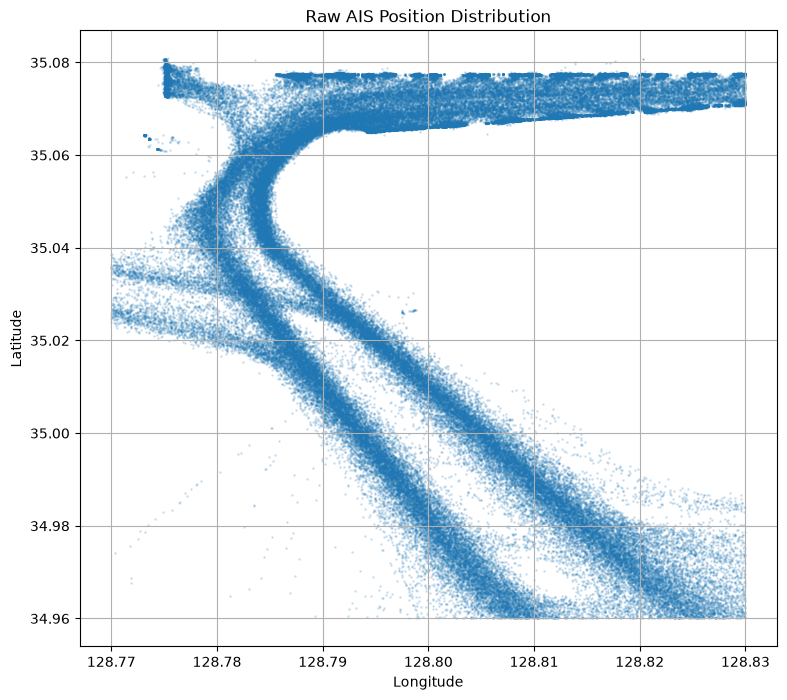

In [35]:
# Raw AIS 위치 분포

raw_plot_df = df_raw.copy()

raw_plot_df["Lat"] = pd.to_numeric(raw_plot_df["Lat"], errors="coerce")
raw_plot_df["Long"] = pd.to_numeric(raw_plot_df["Long"], errors="coerce")
raw_plot_df = raw_plot_df.dropna(subset=["Lat", "Long"])

sample_df = raw_plot_df.sample(
    n=min(200000, len(raw_plot_df)),
    random_state=42
)

plt.figure(figsize=(9, 8))
plt.scatter(
    sample_df["Long"],
    sample_df["Lat"],
    s=1,
    alpha=0.15
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Raw AIS Position Distribution")
plt.grid(True)

ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.ticklabel_format(style="plain", axis="both")

plt.show()

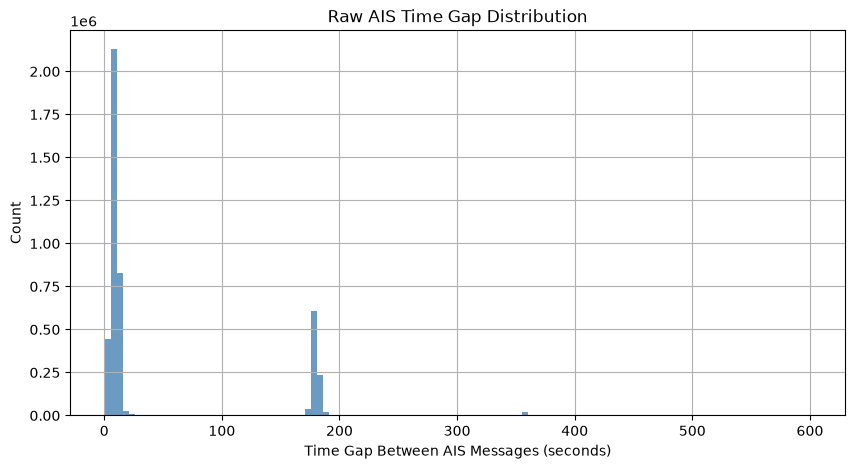

count    4.394190e+06
mean     4.698308e+01
std      7.398173e+01
min      1.000000e+00
10%      5.000000e+00
25%      9.000000e+00
50%      1.000000e+01
75%      1.200000e+01
90%      1.800000e+02
max      6.000000e+02
Name: dt_sec, dtype: float64
30초 이하 비율: 0.7839804378053749
60초 이하 비율: 0.7848572774504516


In [36]:
# Raw AIS 수신 간격 분포

raw_time_df = df.copy().sort_values(["MMSI", "timestamp"])
raw_time_df["dt_sec"] = raw_time_df.groupby("MMSI")["timestamp"].diff().dt.total_seconds()

dt = raw_time_df["dt_sec"].dropna()
dt = dt[(dt > 0) & (dt <= 600)]

plt.figure(figsize=(10, 5))
plt.hist(dt, bins=120, color="steelblue", alpha=0.8)
plt.xlabel("Time Gap Between AIS Messages (seconds)")
plt.ylabel("Count")
plt.title("Raw AIS Time Gap Distribution")
plt.grid(True)
plt.show()

print(dt.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))
print("30초 이하 비율:", (dt <= 30).mean())
print("60초 이하 비율:", (dt <= 60).mean())

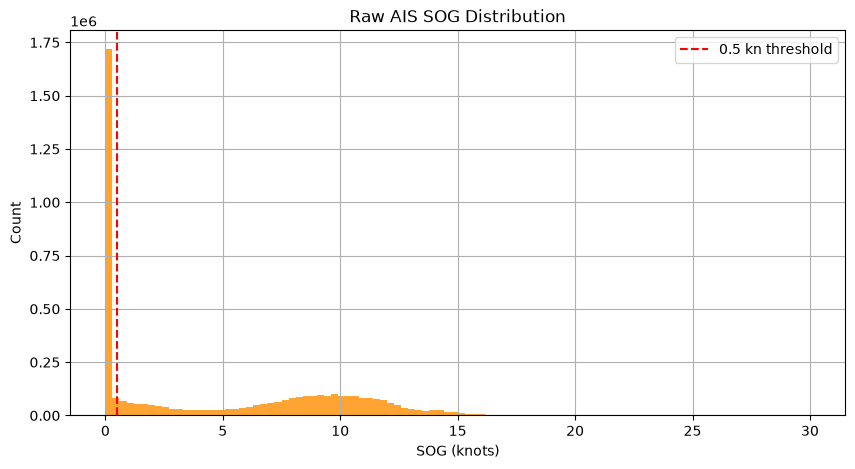

count    4.416856e+06
mean     4.804657e+00
std      4.930283e+00
min      0.000000e+00
25%      0.000000e+00
50%      3.000000e+00
75%      9.400000e+00
max      3.000000e+01
Name: sog, dtype: float64
SOG <= 0.5 비율: 0.408250348211488
SOG <= 1.0 비율: 0.4323430512563688


In [37]:
# Raw AIS SOG 분포

sog = df["sog"].dropna()
sog = sog[(sog >= 0) & (sog <= 30)]

plt.figure(figsize=(10, 5))
plt.hist(sog, bins=100, color="darkorange", alpha=0.8)
plt.axvline(0.5, color="red", linestyle="--", label="0.5 kn threshold")
plt.xlabel("SOG (knots)")
plt.ylabel("Count")
plt.title("Raw AIS SOG Distribution")
plt.grid(True)
plt.legend()
plt.show()

print(sog.describe())
print("SOG <= 0.5 비율:", (sog <= 0.5).mean())
print("SOG <= 1.0 비율:", (sog <= 1.0).mean())

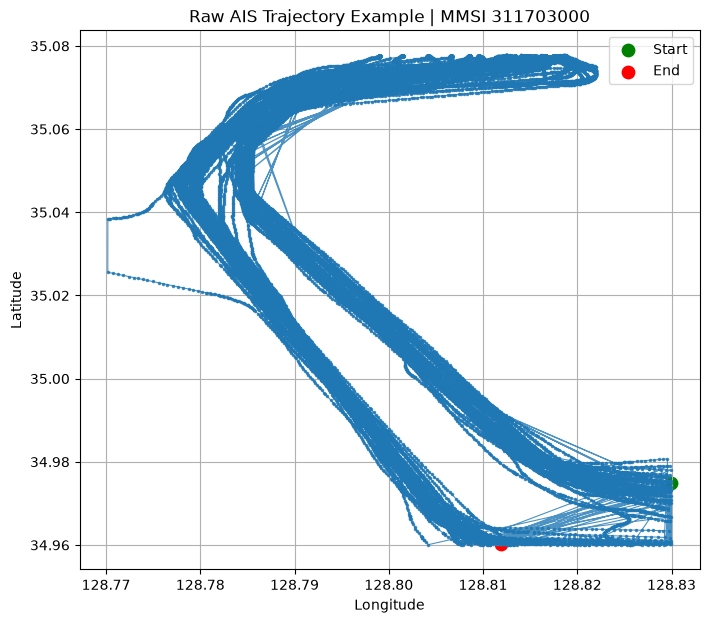

MMSI: 311703000
points: 51422
time range: 2024-04-03 14:58:48 ~ 2024-08-31 01:35:02


In [38]:
# Raw AIS 개별 선박 trajectory 예시

def plot_raw_vessel_trajectory(raw_df, mmsi=None, min_points=100):
    temp = raw_df.copy()

    if mmsi is None:
        counts = temp["MMSI"].value_counts()
        candidate_mmsi = counts[counts >= min_points].index[0]
    else:
        candidate_mmsi = mmsi

    vessel_df = temp[temp["MMSI"] == candidate_mmsi].sort_values("timestamp").copy()

    plt.figure(figsize=(8, 7))
    plt.plot(
        vessel_df["lon"],
        vessel_df["lat"],
        marker=".",
        markersize=3,
        linewidth=0.8,
        alpha=0.8
    )

    plt.scatter(
        vessel_df.iloc[0]["lon"],
        vessel_df.iloc[0]["lat"],
        color="green",
        s=80,
        label="Start"
    )

    plt.scatter(
        vessel_df.iloc[-1]["lon"],
        vessel_df.iloc[-1]["lat"],
        color="red",
        s=80,
        label="End"
    )

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"Raw AIS Trajectory Example | MMSI {candidate_mmsi}")
    plt.grid(True)
    plt.legend()

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style="plain", axis="both")

    plt.show()

    print("MMSI:", candidate_mmsi)
    print("points:", len(vessel_df))
    print("time range:", vessel_df["timestamp"].min(), "~", vessel_df["timestamp"].max())


plot_raw_vessel_trajectory(df)

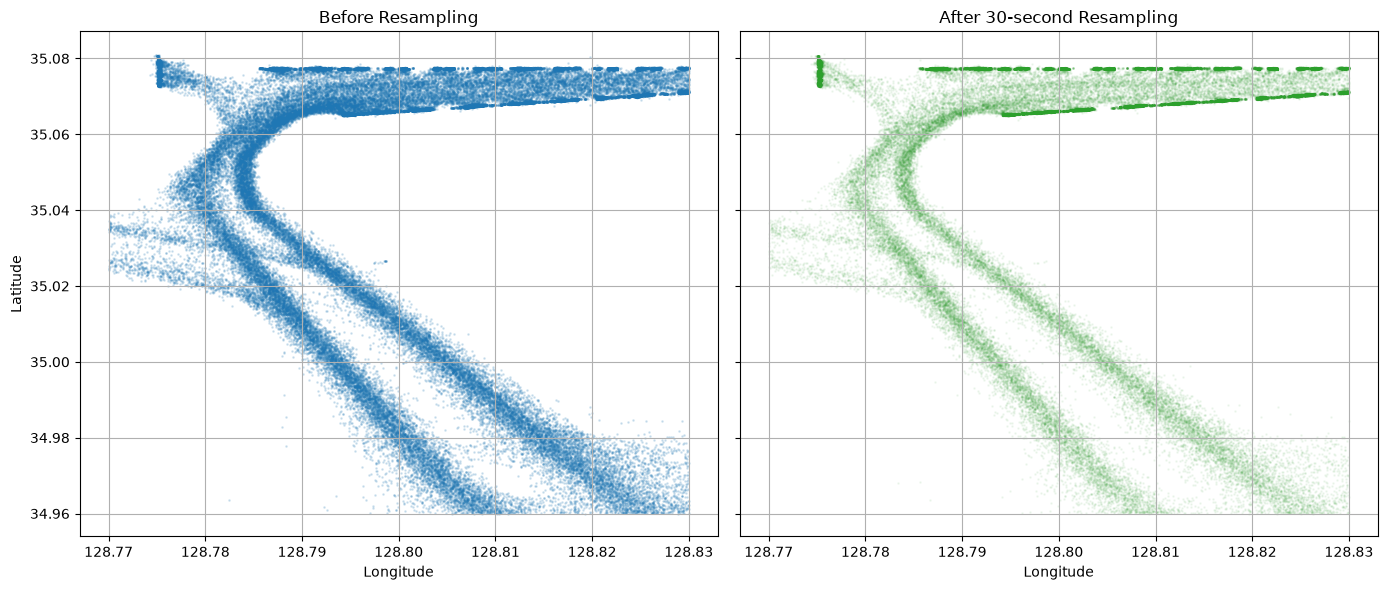

Before rows: 4417967
After rows: 1998821
Before sample: (100000, 9)
After sample: (100000, 12)


In [49]:
# 전처리 전후 위치 분포 비교
# before: 기본 전처리 후 원본 df
# after: 30초 리샘플링 후 train/val/test 합친 데이터

before_df = df.sample(n=min(100000, len(df)), random_state=42)

resampled_parts = []

if "train_raw" in globals():
    resampled_parts.append(train_raw)

if "val_raw" in globals():
    resampled_parts.append(val_raw)

if "test_raw" in globals():
    resampled_parts.append(test_raw)

if len(resampled_parts) == 0:
    raise ValueError("train_raw, val_raw, test_raw가 없습니다. 7번 리샘플링 셀 실행 후 다시 실행하세요.")

resampled_df = pd.concat(resampled_parts, ignore_index=True)

after_df = resampled_df.sample(
    n=min(100000, len(resampled_df)),
    random_state=42
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

axes[0].scatter(
    before_df["lon"],
    before_df["lat"],
    s=1,
    alpha=0.15
)
axes[0].set_title("Before Resampling")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].grid(True)

axes[1].scatter(
    after_df["lon"],
    after_df["lat"],
    s=0.8,
    alpha=0.06,
    color="tab:green"
)
axes[1].set_title("After 30-second Resampling")
axes[1].set_xlabel("Longitude")
axes[1].grid(True)

for ax in axes:
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style="plain", axis="both")

plt.tight_layout()
plt.show()

print("Before rows:", len(df))
print("After rows:", len(resampled_df))
print("Before sample:", before_df.shape)
print("After sample:", after_df.shape)

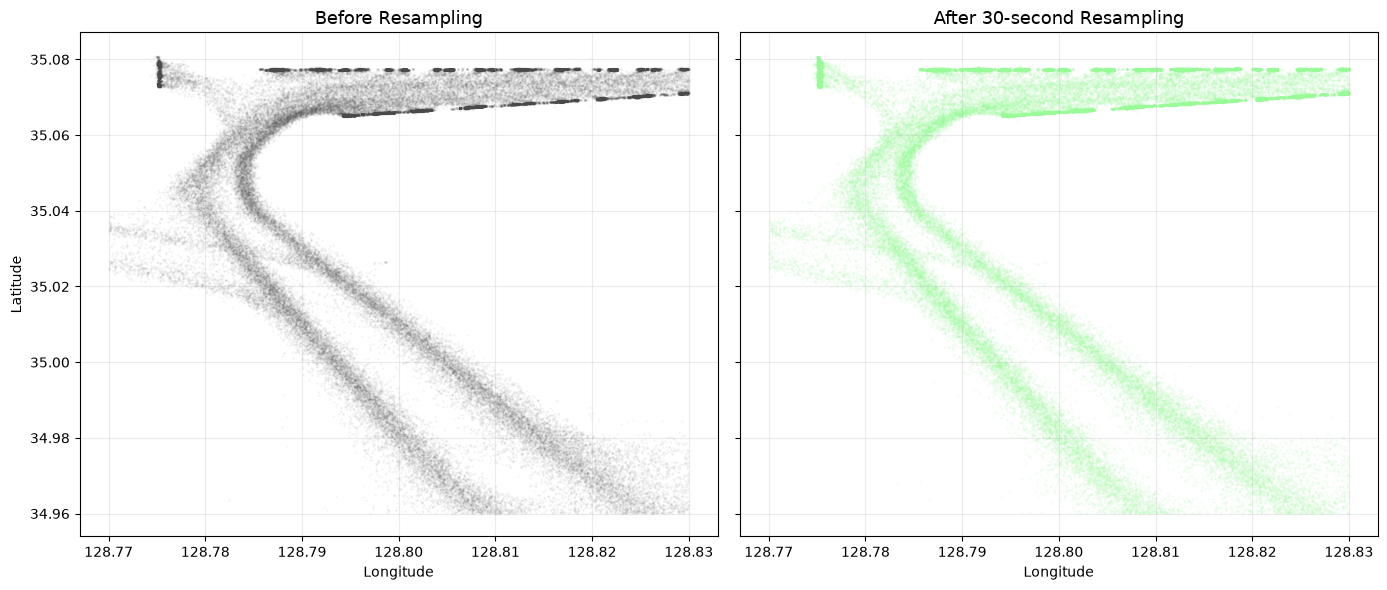

Before rows: 4417967
After rows: 1998821
Before sample: (100000, 9)
After sample: (100000, 12)


In [44]:
# 전처리 전후 위치 분포 비교
# before: 기본 전처리 후 원본 df
# after: 30초 리샘플링 후 train/val/test 합친 데이터

before_df = df.sample(n=min(100000, len(df)), random_state=42)

resampled_parts = []

if "train_raw" in globals():
    resampled_parts.append(train_raw)

if "val_raw" in globals():
    resampled_parts.append(val_raw)

if "test_raw" in globals():
    resampled_parts.append(test_raw)

if len(resampled_parts) == 0:
    raise ValueError("train_raw, val_raw, test_raw가 없습니다. 7번 리샘플링 셀 실행 후 다시 실행하세요.")

resampled_df = pd.concat(resampled_parts, ignore_index=True)

after_df = resampled_df.sample(
    n=min(100000, len(resampled_df)),
    random_state=42
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    sharex=True,
    sharey=True
)

# 전처리 전: 탁하고 복잡한 느낌
axes[0].scatter(
    before_df["lon"],
    before_df["lat"],
    s=0.7,
    alpha=0.045,
    color="#4A4A4A"
)
axes[0].set_title("Before Resampling", fontsize=13)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].grid(True, alpha=0.25)

# 전처리 후: 밝고 정돈된 느낌
axes[1].scatter(
    after_df["lon"],
    after_df["lat"],
    s=0.8,
    alpha=0.08,
    color="#98FB98"
)
axes[1].set_title("After 30-second Resampling", fontsize=13)
axes[1].set_xlabel("Longitude")
axes[1].grid(True, alpha=0.25)

for ax in axes:
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style="plain", axis="both")

plt.tight_layout()
plt.show()

print("Before rows:", len(df))
print("After rows:", len(resampled_df))
print("Before sample:", before_df.shape)
print("After sample:", after_df.shape)